<img src="imgs/unifor_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos para Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

<p dir="ltr" style="text-align: left;">
    <strong>Links:</strong>
    <a href="https://www2.unifor.br/controle_pesquisa/pesquisarprofessor.do?actionParameter=prepareUpdate&amp;p_tp_ambiente=2&amp;p_tp_chamada=1&amp;p_tp_apresentacao=1&amp;cdPesquisador=767686193" target="_blank">Unifor</a> |
    <a href="http://lattes.cnpq.br/5738786447903616" target="_blank">Lattes</a> |
    <a href="https://unifor.br/web/pesquisa-inovacao/ncdia" target="_blank">NCDIA</a> |
    <a href="https://github.com/carubbi/" target="_blank">Github</a>
</p>


# Variáveis Aleatórias Contínuas e suas Distribuições de Probabilidade

Uma [variável aleatória](https://en.wikipedia.org/wiki/Random_variable) cujos valores **não são contáveis** é chamada de **variável aleatória contínua**. Uma variável aleatória contínua é uma variável aleatória que pode assumir **qualquer valor contido em um ou mais intervalos**. Como a quantidade de valores contidos em qualquer intervalo é **infinita**, o número possível de valores que uma variável aleatória contínua pode assumir também é infinito (Mann, 2012).

Existem muito [mais distribuições de probabilidade contínuas](https://en.wikipedia.org/wiki/List_of_probability_distributions) do que podemos discutir aqui. No entanto, esteja ciente de que a biblioteca Python `scipy.stats` implementa uma grande variedade de diferentes distribuições de probabilidade discretas e contínuas ([veja aqui](https://docs.scipy.org/doc/scipy/reference/stats.html)).

Em geral, as funções de probabilidade em Python são acessíveis chamando diferentes métodos após a chamada da distribuição de probabilidade. Para distribuições **contínuas**, os métodos mais usados nesta aula serão:

- `rvs`: gera observações aleatórias (*random variates*), como `uniform.rvs()` ou `norm.rvs()`;
- `pdf`: calcula a função densidade de probabilidade, como `uniform.pdf()` ou `norm.pdf()`;
- `cdf`: calcula a função de distribuição acumulada, como `uniform.cdf()` ou `norm.cdf()`;
- `sf`: calcula diretamente a cauda superior, isto é, `1 - cdf(x)`, com maior estabilidade numérica em caudas;
- `ppf`: calcula o inverso da CDF, isto é, o quantil associado a uma probabilidade acumulada, como `uniform.ppf()` ou `norm.ppf()`.

A função `pmf` (*probability mass function*) é própria de distribuições **discretas**, como binomial ou Poisson, e não deve ser usada para representar densidades contínuas.


## A Distribuição de Variáveis Aleatórias Contínuas

A forma da distribuição de uma variável aleatória pode ser visualizada por meio de uma curva suave. Tais curvas, que representam a distribuição de variáveis contínuas, são chamadas de **funções densidade de probabilidade** (*Probability Density Functions*, **PDFs**) ou simplesmente **funções densidade**. As funções densidade de probabilidade possuem três propriedades principais (Mann, 2012; Weiss, 2010):

1. O gráfico de uma PDF está sempre **sobre ou acima** do eixo horizontal — isto é, $f_X(x) \ge 0$ para todo $x$.
2. A **área total** sob a PDF (e acima do eixo horizontal) é igual a **1**; logo, qualquer probabilidade associada a um intervalo está no intervalo de $0$ a $1$.
3. A **probabilidade** de que a variável assuma um valor dentro de qualquer intervalo especificado é igual à **área correspondente** sob a função densidade nesse intervalo e pode ser expressa como porcentagens ou proporções.

A área total sob a curva é dada pela integral da densidade de $-\infty$ a $+\infty$, a qual resulta em $1$:
$$
\int_{-\infty}^{+\infty} f_X(x)\,dx = 1.
$$

In [1]:
# Primeiro, vamos importar todas as bibliotecas necessárias.
import os
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

# Define um estilo padrão para manter os gráficos consistentes.
plt.style.use("ggplot")

# Configura tamanhos padrão para títulos, eixos, legendas e textos.
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.size': 12,
    'figure.autolayout': True
})

# Gerador pseudoaleatório compartilhado para reprodutibilidade.
rng = np.random.default_rng(42)

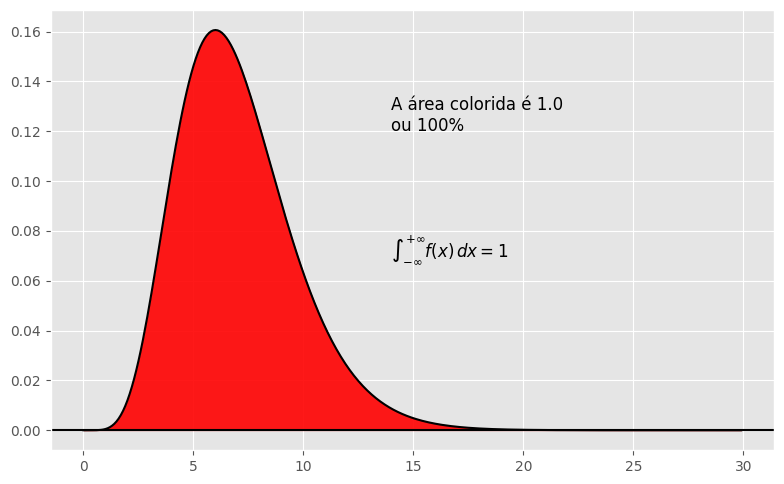

In [2]:
# Parâmetros da distribuição Gama e limites do sombreamento.
shape = 7
rate = 1
cut_a = 1
cut_b = 4.5

# Desenha a PDF para lembrar que a área total sob a curva é 1.
plt.figure()
plt.plot(
    np.arange(0, 30, 0.1),
    stats.gamma.pdf(np.arange(0, 30, 0.1), shape, scale=1 / rate),
    color="black",
)

# Destacamos toda a área sob a curva (probabilidade total).
plt.fill_between(
    x=np.arange(0, 30, 0.1),
    y1=stats.gamma.pdf(np.arange(0, 30, 0.1), shape, scale=1 / rate),
    color="red",
    alpha=0.9,
)

plt.axhline(0, color="black")

plt.text(14, 0.12, "A área colorida é 1.0\nou 100%")
plt.text(14, 0.07, r"$\int_{-\infty}^{+\infty} f(x)\,dx = 1$")
plt.show()


A probabilidade de que uma variável aleatória contínua $X$ assuma um valor dentro de um certo intervalo é dada pela **área sob a curva** entre os dois limites desse intervalo. A área colorida sob a curva para o intervalo $(-\infty,\, a]$ (painel esquerdo) e para o intervalo $[a,\, \infty)$ (painel direito) é mostrada na figura abaixo.

A probabilidade de que $X$ caia no intervalo $(-\infty,\, a]$ é
$$
P(X \le a) \;=\; \int_{-\infty}^{a} f(x)\,dx.
$$

E a probabilidade de que $X$ caia no intervalo $[a,\, \infty)$ é
$$
P(X \ge a) \;=\; 1 - P(X \le a) \;=\; \int_{a}^{\infty} f(x)\,dx.
$$

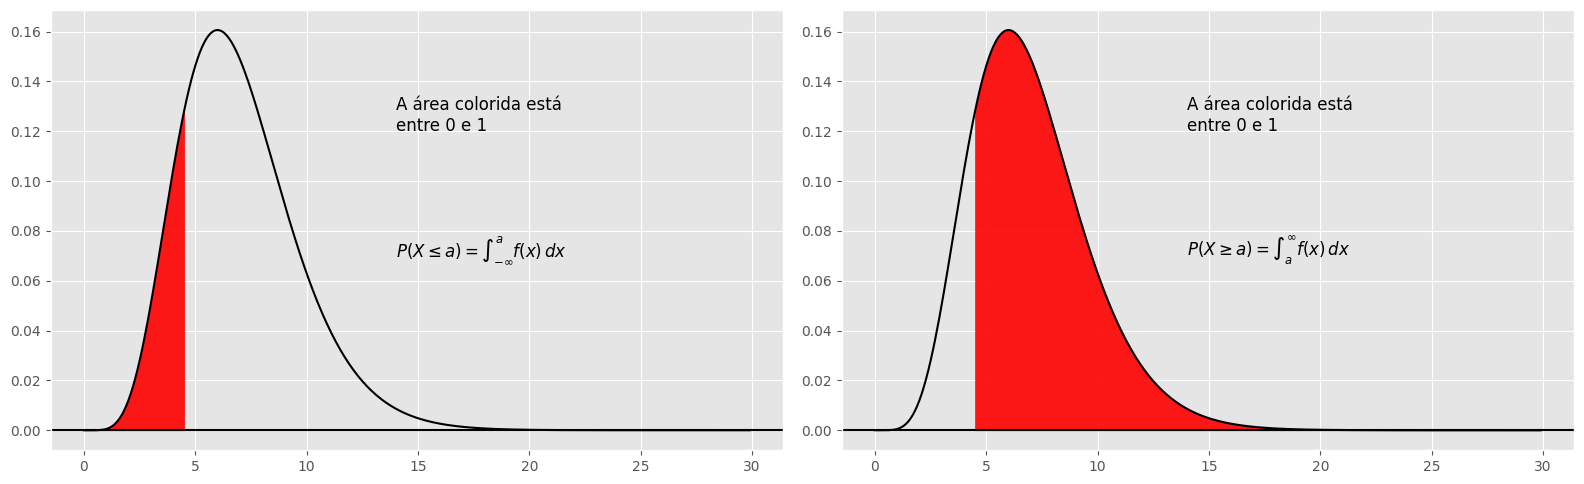

In [3]:
# Reutilizamos os parâmetros da Gama para comparar caudas complementares.
shape = 7
rate = 1
cut_a = 1
cut_b = 4.5

# Monta dois subplots lado a lado para destacar probabilidades à esquerda e à direita.
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

## gráfico 1
ax[0].plot(
    np.arange(0, 30, 0.1),
    stats.gamma.pdf(np.arange(0, 30, 0.1), shape, scale=1 / rate),
    color="black",
)

# Área acumulada até o ponto cut_b (cauda inferior).
ax[0].fill_between(
    x=np.arange(0, 30, 0.1),
    y1=stats.gamma.pdf(np.arange(0, 30, 0.1), shape, scale=1 / rate),
    where=(np.arange(0, 30, 0.1) <= cut_b),
    color="red",
    alpha=0.9,
)

ax[0].axhline(0, color="black")

ax[0].text(14, 0.12, "A área colorida está\nentre 0 e 1")
ax[0].text(14, 0.07, r"$P(X\leq a) = \int_{-\infty}^{a} f(x)\,dx$")

## gráfico 2
ax[1].plot(
    np.arange(0, 30, 0.1),
    stats.gamma.pdf(np.arange(0, 30, 0.1), shape, scale=1 / rate),
    color="black",
)

# Área acumulada a partir de cut_b (cauda superior).
ax[1].fill_between(
    x=np.arange(0, 30, 0.1),
    y1=stats.gamma.pdf(np.arange(0, 30, 0.1), shape, scale=1 / rate),
    where=(np.arange(0, 30, 0.1) >= cut_b),
    color="red",
    alpha=0.9,
)

ax[1].axhline(0, color="black")

ax[1].text(14, 0.12, "A área colorida está\nentre 0 e 1")
ax[1].text(14, 0.07, r"$P(X\geq a) = \int_{a}^{\infty} f(x)\,dx$")

plt.show()

A probabilidade de que uma variável aleatória contínua $X$ assuma um valor dentro de um certo intervalo é dada pela **área sob a curva** entre os dois limites desse intervalo. A área colorida sob a curva de $a$ até $b$ na figura abaixo fornece a probabilidade de que $X$ caia no intervalo $[a,\, b]$.

$$
P(a \le X \le b) \;=\; \int_{a}^{b} f(x)\,dx.
$$

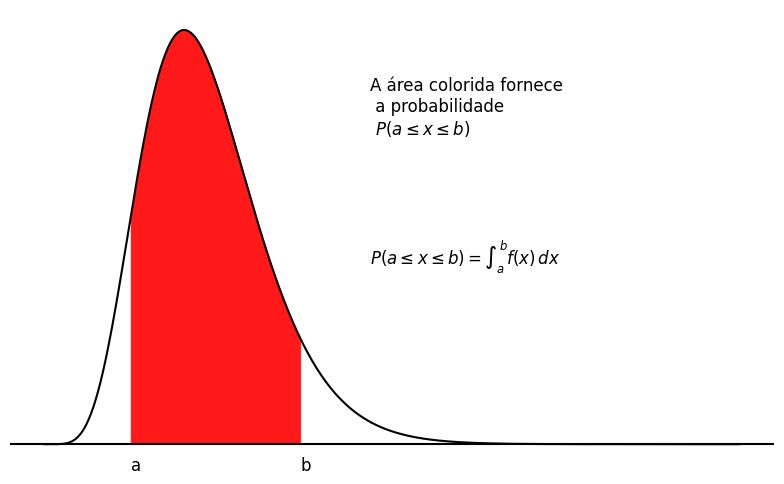

In [4]:
# Parâmetros e limites a e b usados para calcular P(a <= X <= b).
shape = 7
rate = 1
cut_a = 3.7
cut_b = 11

plt.figure()
plt.plot(
    np.arange(0, 30, 0.1),
    stats.gamma.pdf(np.arange(0, 30, 0.1), shape, scale=1 / rate),
    color="black",
)

# Sombreamos apenas o intervalo de interesse entre a e b.
plt.fill_between(
    x=np.arange(0, 30, 0.1),
    y1=stats.gamma.pdf(np.arange(0, 30, 0.1), shape, scale=1 / rate),
    where=(np.arange(0, 30, 0.1) >= cut_a) & (np.arange(0, 30, 0.1) <= cut_b),
    color="red",
    alpha=0.9,
)

plt.axhline(0, color="black")
plt.axis("off")

plt.text(
    14,
    0.12,
    "A área colorida fornece\n a probabilidade\n $P(a \\leq x \\leq b)$",

)
plt.text(14, 0.07, r"$P(a \leq x \leq b) = \int_a^b f(x)\,dx$")
plt.text(3.7, -0.01, "a")
plt.text(11, -0.01, "b")

plt.show()

Observe que o intervalo $a \le x \le b$ afirma que $x$ é **maior ou igual a** $a$ e **menor ou igual a** $b$.

Para uma distribuição de probabilidade **contínua**, a probabilidade é sempre calculada sobre **um intervalo**. A probabilidade de que uma variável aleatória contínua $X$ assuma **um único valor** é sempre **zero**. Isso ocorre porque a probabilidade de escolher exatamente um valor dentre um número infinito de valores em $\mathbb{R}$ é zero. Em termos geométricos, isso significa que a **área** de uma “linha” que representa um ponto único é zero:
$$
P(X = x) = 0.
$$

Disso, podemos deduzir que, para uma variável aleatória contínua,
$$
P(a \le X \le b) \;=\; P(a < X < b).
$$

Em outras palavras, a probabilidade de que $X$ assuma um valor no intervalo de $a$ a $b$ é a mesma **incluindo ou não** os pontos extremos $a$ e $b$.

### Esperança, variância, desvio-padrão e coeficiente de variação para VAC

Além de calcular probabilidades por áreas sob a densidade, também usamos medidas-resumo para descrever variáveis aleatórias contínuas. Para uma variável aleatória contínua $X$ com densidade $f_X(x)$, a esperança é definida por

$$
E(X)=\mu=\int_{-\infty}^{+\infty} x f_X(x)\,dx.
$$

A variância mede o espalhamento em torno da média:

$$
Var(X)=E[(X-\mu)^2]=\int_{-\infty}^{+\infty}(x-\mu)^2 f_X(x)\,dx.
$$

O desvio-padrão é

$$
DP(X)=\sqrt{Var(X)}.
$$

Quando $\mu\ne 0$, o coeficiente de variação pode ser usado como medida relativa de dispersão:

$$
CV(X)=\frac{DP(X)}{E(X)}.
$$

Se $E(X)=0$, o coeficiente de variação não é definido, pois envolveria divisão por zero. Essa observação será usada no caso do erro de arredondamento uniforme.


### Densidade contínua genérica

Considere um tempo de atendimento $T$ descrito por uma densidade contínua específica. O ponto didático é separar três tarefas:

- probabilidades são áreas sob a densidade;
- a média é calculada por $E(T)=\int t f_T(t)\,dt$;
- a variância é calculada a partir da dispersão em torno da média.

Para esse caso, considere os seguintes resultados:

$$
E(T)=4\text{ minutos},\qquad Var(T)=8,
\qquad DP(T)=2.83,
\qquad CV(T)=0.707.
$$

Esse tipo de comparação reforça a interpretação visual: deslocar uma densidade altera a média; espalhar a densidade em torno do centro altera a variância.


In [5]:
# Interpretação de média, variância, DP e CV.
media_T = 4
var_T = 8
dp_T = np.sqrt(var_T)
cv_T = dp_T / media_T

print(f"E(T) = {media_T:.0f} minutos")
print(f"Var(T) = {var_T:.0f}")
print(f"DP(T) = {dp_T:.2f}")
print(f"CV(T) = {cv_T:.3f}")


E(T) = 4 minutos
Var(T) = 8
DP(T) = 2.83
CV(T) = 0.707


## A Distribuição Normal  
A distribuição normal é amplamente utilizada em teoria das probabilidades, estatística e nas ciências naturais e sociais. Ela também é chamada de **distribuição Gaussiana**, porque Carl Friedrich Gauss (1777–1855) foi um dos primeiros a aplicá-la na análise de dados astronômicos (Lovrić, 2011) ([vídeo](https://userpage.fu-berlin.de/soga/Videos/NormalDistribution.mp4)).


### Vídeo: O que é uma distribuição normal?

Assista ao vídeo explicativo sobre a **Distribuição estatística** neste [link](https://youtu.be/oI3hZJqXJuc?si=N-y6ayu-hLQ2IkP8) ou visualize o vídeo diretamente no notebook abaixo:

[<img src="https://drive.google.com/uc?id=1Zc3vzxmNHO8jqxiQYXRLAS9HgFZu2YZR" width="400">](https://youtu.be/rzFX5NWojp0?si=UAt3NX7jsPXWOhta)

A **distribuição normal** (ou **curva normal**) é uma curva em forma de sino, **simétrica**. Sua média é denotada por $\,\mu\,$ e seu desvio-padrão por $\,\sigma\,$. Uma variável aleatória contínua $X$ que segue uma distribuição normal é chamada de **variável aleatória normal**.

A notação para a distribuição normal é $X \sim \mathcal{N}(\mu, \sigma)$. A função densidade de probabilidade (PDF) é dada por

$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left( \frac{x - \mu}{\sigma} \right)^2}
$$

Aqui, $e \approx 2.7182818$ (base dos logaritmos naturais) e $\pi \approx 3.14159$. A função densidade $f(x)$ fornece a **altura da curva** no ponto $x$; esse valor é densidade, não probabilidade pontual. Probabilidades em variáveis contínuas são obtidas por áreas sob a curva em intervalos.

A distribuição normal é descrita por **dois parâmetros**: a média $\mu$ e o desvio-padrão $\sigma$. Cada par $(\mu,\sigma)$ determina uma curva normal diferente: o valor de $\mu$ define o **centro** da curva no eixo horizontal, enquanto o valor de $\sigma$ determina a **dispersão** (ou “largura”) da curva normal.

### Convenção de parâmetros da Normal no texto e no Python

Em textos de estatística, é comum escrever a distribuição normal como $X\sim N(\mu,\sigma^2)$, isto é, o segundo parâmetro é a **variância**. Neste notebook, quando usamos a API do `scipy.stats`, a convenção é diferente: `loc` é a média $\mu$ e `scale` é o **desvio-padrão** $\sigma$.

Assim, se a notação matemática for

$$
X\sim N(70, 10^2),
$$

em Python usamos:

```python
stats.norm(loc=70, scale=10)
```

Essa diferença é uma fonte comum de erro: nunca passe $\sigma^2$ no argumento `scale`.


<img src="imgs/normalDIst_1.png" width="800">

<img src="imgs/normalDIst_2.png" width="800">

<img src="imgs/normalDIst_3.png" width="800">

### Distribuição Normal Padronizada

A **Distribuição Normal Padronizada**  
A distribuição normal padronizada é um caso especial da distribuição normal. Para a normal padronizada, a média é igual a zero ($\mu = 0$) e o desvio-padrão é igual a 1 ($\sigma = 1$).

Assim, ao substituir $\mu = 0$ e $\sigma = 1$ na PDF da distribuição normal, a equação se simplifica para

\begin{align}
f_Z(z)& = \frac{1}{\sigma \sqrt{2 \pi}}e^{-\frac{1}{2}\left(\frac{z-\mu}{\sigma}\right)^2} \\
& =\frac{1}{1 \times \sqrt{2 \pi}}e^{-\frac{1}{2}\left(\frac{z-0}{1}\right)^2} \\
& = \frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}z^2}.
\end{align}

A variável aleatória que possui a distribuição normal padronizada é denotada por $Z$. Os valores observados nessa escala são chamados de **valores-z**, **escores-z**, **unidades padrão** ou **escores padronizados**.

A **função de distribuição acumulada (CDF)** da normal padronizada corresponde à área sob a curva no intervalo $(-\infty, z]$. Usualmente, a densidade da normal padrão é denotada por $\phi(z)$ e a CDF por $\Phi(z)$:

$$
\Phi(z) = F_Z(z) = P(Z \le z) = \int_{-\infty}^{z}\phi(t)\,dt
= \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{z}e^{-\frac{1}{2}t^2}\,dt.
$$

A integral acima não possui forma fechada elementar; por isso usamos tabelas da normal padrão ou funções computacionais como `stats.norm.cdf()`.

### Propriedades básicas da curva normal padronizada
A curva normal padronizada é um caso especial da distribuição normal e, portanto, também é uma **curva de distribuição de probabilidade**. Assim, as propriedades básicas da distribuição normal valem igualmente para a curva normal padronizada (Weiss, 2010).

- A **área total** sob a curva normal padronizada é **1** (propriedade compartilhada por todas as curvas de densidade).
- A curva normal padronizada **se estende indefinidamente** em ambas as direções, **aproximando-se**, mas **nunca tocando**, o eixo horizontal.
- A curva normal padronizada tem **forma de sino** e é **centrada em $z=0$**. **Quase toda** a área sob a curva normal padronizada está entre $z=-3$ e $z=3$.


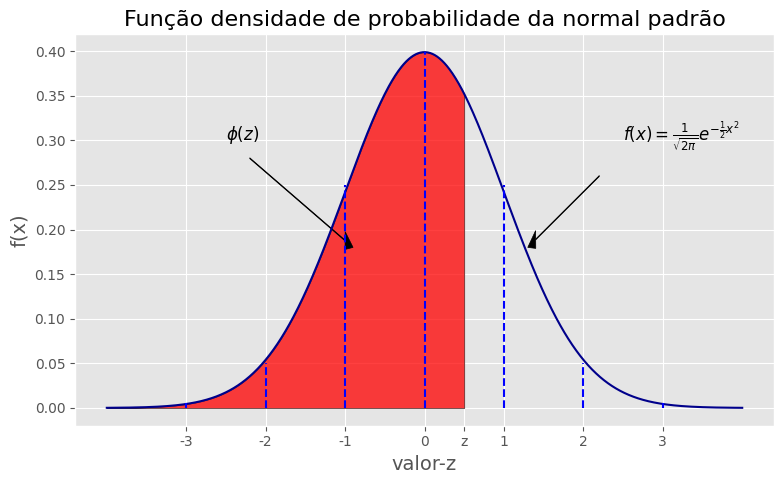

In [6]:
# Constrói a PDF da normal padrão e destaca a área até 0.5 desvios.
mu = 0
sigma = 1
cut_a = -4
cut_b = 0.5

# Gera a PDF da normal padrão em um grid simétrico ao redor da média.
x = np.arange(-4, 4.01, 0.01)
yy = stats.norm.pdf(x, mu, sigma)

plt.figure()
plt.plot(x, yy, color="darkblue")

plt.title("Função densidade de probabilidade da normal padrão")
plt.xticks(
    [
        mu - 3 * sigma,
        mu - 2 * sigma,
        mu - sigma,
        mu,
        0.5,
        mu + sigma,
        mu + 2 * sigma,
        mu + 3 * sigma,
    ],
    [-3, -2, -1, 0, "z", 1, 2, 3],
)

# A área vermelha representa P(Z \leq 0.5) na curva normal padrão.
plt.fill_between(
    x=x,
    y1=yy,
    where=(x <= 0.5),
    color="red",
    edgecolor="black",
    alpha=0.75,
)

xpos = [-3, -2, -1, 0, 1, 2, 3]
ypos = [0.005, 0.05, 0.25, max(yy), 0.25, 0.05, 0.005]
# Linhas tracejadas indicam múltiplos inteiros do desvio-padrão.
for px, py in zip(xpos, ypos):
    plt.vlines(x=mu + px, ymin=0, ymax=py, color="blue", linestyle="--")

plt.text(
    2.5, 0.3, r"$f(x) = \frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2} x^2}$"
)

plt.arrow(
    2.2,
    0.26,
    -0.9,
    -0.08,
    length_includes_head=True,
    head_width=0.02,
    head_length=0.1,
    color="black",
)

plt.arrow(
    -2.2,
    0.28,
    1.3,
    -0.1,
    length_includes_head=True,
    head_width=0.02,
    head_length=0.1,
    color="black",
)

plt.text(-2.5, 0.3, r"$\phi(z)$")
plt.xlabel("valor-z")
plt.ylabel("f(x)")
plt.show()


Os valores-$z$ à **direita** da média são **positivos** e aqueles à **esquerda** são **negativos**. O valor-$z$ de um ponto no eixo horizontal indica a **distância entre a média** ($z=0$) **e esse ponto em unidades de desvio-padrão**. Por exemplo, um ponto com $z=2$ está **dois desvios-padrão à direita** da média. De modo análogo, um ponto com $z=-2$ está **dois desvios-padrão à esquerda** da média.

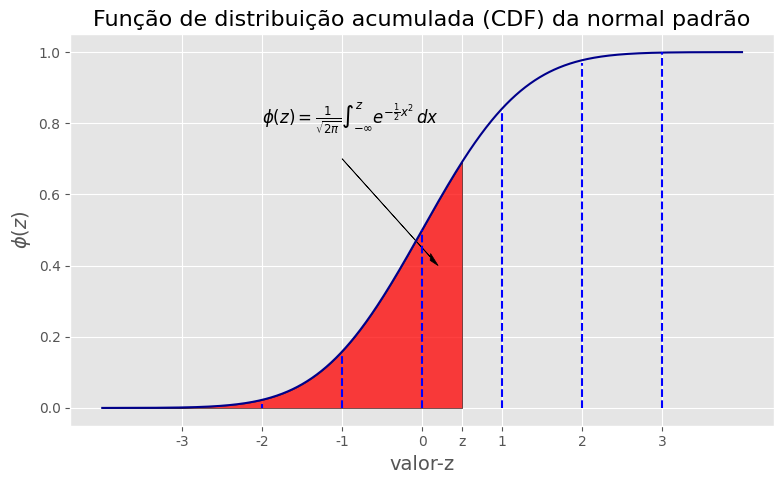

In [7]:
# Parâmetros da normal padrão utilizados para a CDF.
mu = 0
sigma = 1
cut_a = -4
cut_b = 0.5

# Calcula a CDF da normal padrão no mesmo grid simétrico.
x = np.arange(-4, 4.01, 0.01)
yy = stats.norm.cdf(x, mu, sigma)

plt.figure()
plt.plot(x, yy, color="darkblue")

plt.title("Função de distribuição acumulada (CDF) da normal padrão")
plt.xlabel("valor-z")
plt.ylabel(r"$\phi(z)$")
plt.xticks(
    [
        mu - 3 * sigma,
        mu - 2 * sigma,
        mu - sigma,
        mu,
        0.5,
        mu + sigma,
        mu + 2 * sigma,
        mu + 3 * sigma,
    ],
    [-3, -2, -1, 0, "z", 1, 2, 3],
)

# Área acumulada até o ponto indicado pela seta.
plt.fill_between(
    x=x,
    y1=yy,
    where=(x <= 0.5),
    color="red",
    edgecolor="black",
    alpha=0.75,
)

xpos = [-3, -2, -1, 0, 1, 2, 3]
ypos = [0.0001, 0.01, 0.15, 0.5, 0.83, 0.97, max(yy)]
# Referências verticais ajudam a enxergar quantis notáveis.
for px, py in zip(xpos, ypos):
    plt.vlines(x=mu + px, ymin=0, ymax=py, color="blue", linestyle="--")

plt.arrow(
    -1,
    0.7,
    1.2,
    -0.3,
    length_includes_head=True,
    head_width=0.02,
    head_length=0.1,
    color="black",
)

plt.text(
    -2,
    0.8,
    r"$\phi(z) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{z} e^{-\frac{1}{2}x^2}\,dx$",

)

plt.show()


O conceito de determinar probabilidades calculando a **área sob a curva normal padronizada** é amplamente aplicado. Por isso existem **tabelas de probabilidade** para consultar a área correspondente a um determinado valor-$z$. No entanto, o **Python** é uma ferramenta tão poderosa que podemos calcular a área sob a curva para qualquer valor-$z$ específico.

Para calcular a área sob a curva de uma **distribuição normal padrão**, aplicamos o método **cdf** do módulo `scipy.stats` usando a função `norm`. A função `scipy.stats.norm.cdf()` é definida como `cdf(x, loc=0, scale=1)`. O argumento `loc` especifica a **média**, enquanto `scale` especifica o **desvio-padrão**. Além disso, observamos que os valores padrão para a média e o desvio-padrão são $0$ e $1$, respectivamente. Assim, a função `cdf()`, aplicada à **normal padrão**, se simplifica para `stats.norm.cdf(q)`. Calculamos a área sob a curva para $z = -3, -2, -1, 0, 1, 2, 3$, ou, de forma mais formal:

$$
P(x \le z) \qquad \text{para } z \in (-3, -2, -1, 0, 1, 2, 3)
$$

In [8]:
# Probabilidades acumuladas para alguns valores fixos de z.
print("P(Z <= -3) =", stats.norm.cdf(-3))
print("P(Z <= -2) =", stats.norm.cdf(-2))
## e assim por diante...

P(Z <= -3) = 0.001349898031630093
P(Z <= -2) = 0.022750131948179198


In [9]:
## ... ou de forma simplificada em um loop:
# Calcula automaticamente as áreas acumuladas para uma lista de z-scores.
z = [-3, -2, -1, 0, 1, 2, 3]
# Cada iteração mostra a probabilidade à esquerda de z.
for i in z:
    print(i, "->", stats.norm.cdf(i))

-3 -> 0.001349898031630093
-2 -> 0.022750131948179198
-1 -> 0.15865525393145707
0 -> 0.5
1 -> 0.8413447460685429
2 -> 0.9772498680518208
3 -> 0.9986501019683699


Os cálculos acima confirmam algumas propriedades da curva normal padronizada. Calculamos a área sob a curva para o intervalo $(-\infty, z]$. Ao chamar `stats.norm.cdf(-3)`, obtemos um número muito pequeno: cerca de **0.135%** da área total está à esquerda de $z=-3$, o que corresponde a uma distância de **3 desvios-padrão** em relação à média. Além disso, `stats.norm.cdf(0)` resulta em **0.5** (**50%**). Assim, a área sob a curva no intervalo $(-\infty, 0]$ é a mesma que no intervalo $[0, \infty)$, e a área total sob a curva é **1**. Por fim, `stats.norm.cdf(3)` fornece um valor alto, aproximadamente **99.865%**, restando cerca de **0.135%** além de $z=3$.

Recorde que podemos calcular explicitamente a área sob a curva para qualquer intervalo de interesse:
\begin{align}
P(a \le Z \le b) &= P(Z \le b) - P(Z \le a) \\
&= \int_{a}^{b} f_Z(z)\,dz \\
&= \int_{-\infty}^{b} f_Z(z)\,dz - \int_{-\infty}^{a} f_Z(z)\,dz.
\end{align}

Vamos calcular a área sob a curva para os seguintes intervalos: $[-1, 1]$, $[-2, 2]$, $[-3, 3]$. Em outras palavras, vamos determinar a área correspondente a $\pm 1$ desvio-padrão, $\pm 2$ desvios-padrão e $\pm 3$ desvios-padrão.


In [10]:
# Proporção de dados contida em 1, 2 e 3 desvios-padrão em torno da média.
for i in range(1, 4):
    print(f"{i}º desvio-padrão: {stats.norm.cdf(i) - stats.norm.cdf(-i)}")

1º desvio-padrão: 0.6826894921370859
2º desvio-padrão: 0.9544997361036416
3º desvio-padrão: 0.9973002039367398


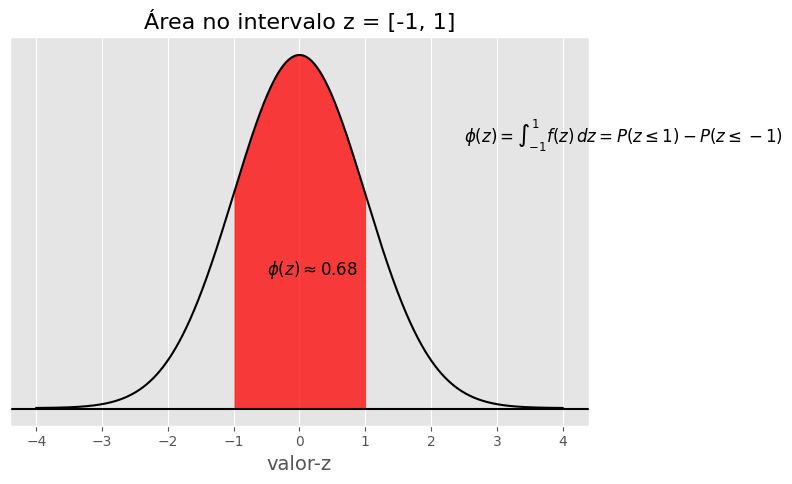

In [11]:
# Calcula e exibe a área central da normal padrão entre -1 e 1 desvios.
mu = 0
sigma = 1
cut_a = -1
cut_b = 1

# PDF da normal padrão usada para sombrear o intervalo central.
x = np.arange(-4, 4.01, 0.01)
yy = stats.norm.pdf(x, mu, sigma)

plt.figure()
plt.plot(x, yy, color="black")

plt.title("Área no intervalo z = [-1, 1]")
plt.yticks([])

# Evidencia a regra empírica: cerca de 68% dentro de [-1, 1].
plt.fill_between(
    x=x,
    y1=yy,
    where=(x >= -1) & (x <= 1),
    color="red",
    alpha=0.75,
)

plt.text(
    2.5,
    0.3,
    r"$\phi(z) = \int_{-1}^{1} f(z)\,dz = P(z \leq 1) - P(z \leq -1)$",

)

plt.text(
    -0.5,
    0.15,
    r"$\phi(z) \approx 0.68$",

)

plt.axhline(-0.001, color="black")
plt.xlabel("valor-z")

plt.show()


### Determinando o valor-$z$ quando a **área sob a curva normal** é conhecida

Até aqui, usamos os escores-$z$ para calcular a área sob a curva. Agora faremos o contrário: calcularemos o(s) escore(s)-$z$ correspondente(s) a uma **área especificada** sob a curva normal padronizada. Encontrar o escore-$z$ que deixa uma área específica é tão frequente que existe uma notação própria: o símbolo $z_\alpha$ é usado para denotar o **escore-$z$ que deixa uma área de $\alpha$ à sua direita** sob a curva normal padrão.

Vamos encontrar $z_{0.05}$, o escore-$z$ que deixa uma área de $0.05$ à sua direita sob a curva normal padrão. O valor de $\alpha$ corresponde à probabilidade de obter um valor no intervalo $[z,\infty)$. Como a área à direita é $0.05$, a área à esquerda é $1 - 0.05 = 0.95$, correspondendo ao intervalo $(-\infty, z]$ (veja o gráfico abaixo).

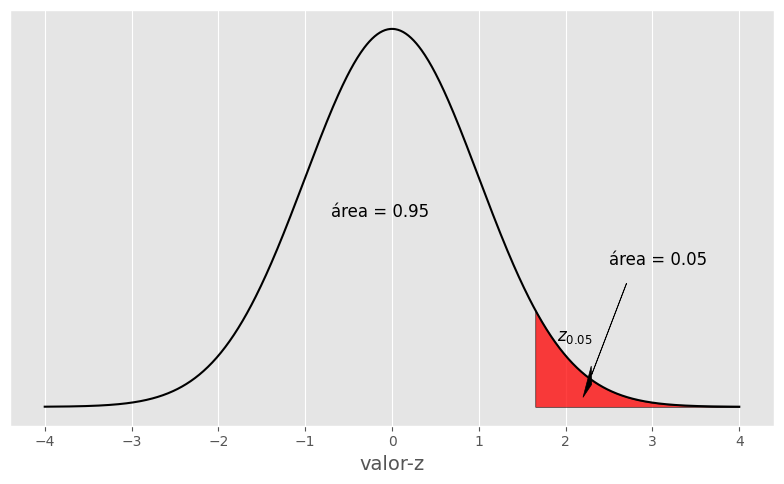

In [12]:
# Ilustra a cauda superior (5%) da normal padrão.
mu = 0
sigma = 1
cut_a = 0.05
cut_b = 4

# Mesma PDF, agora para destacar uma cauda superior específica.
x = np.arange(-4, 4.01, 0.01)
yy = stats.norm.pdf(x, mu, sigma)

plt.figure()
plt.plot(x, yy, color="black")

# Mostra a probabilidade na cauda à direita além de z_{0.05}.
plt.fill_between(
    x=x,
    y1=yy,
    where=(x >= stats.norm.ppf(1 - 0.05)),
    color="red",
    edgecolor="black",
    alpha=0.75,
)

plt.text(2.5, 0.15, "área = 0.05")
plt.text(-0.7, 0.2, "área = 0.95")

plt.text(1.9, 0.07, r"$z_{0.05}$")
plt.arrow(
    2.7,
    0.13,
    -0.5,
    -0.12,
    length_includes_head=True,
    head_width=0.02,
    head_length=0.1,
    color="black",
)

plt.xlabel("valor-z")
plt.yticks([])
plt.show()


Para obter o $z$-score correspondente, podemos consultá-lo em uma **tabela de probabilidades** ou usar **Python**. Para isso, aplicamos o método `norm.ppf()`. A assinatura é `norm.ppf(q, loc=0, scale=1)`. Manteremos os valores padrão de `loc` (média) e `scale` (desvio-padrão).

Contudo, é preciso **cuidado** ao lidar com **cauda inferior** (*lower tail*) e **cauda superior** (*upper tail*):
- Se quisermos o **$z$ da cauda inferior**, o argumento `q` representa a **área à esquerda** de $z$. Portanto, calculamos `norm.ppf(q)`.
- Se quisermos o **$z$ da cauda superior**, o argumento `q` representa a **área à direita** de $z$. Nesse caso, usamos `norm.ppf(1 - q)`.

Vamos ver isso em Python para ficar mais claro.

In [13]:
# Conversão da área acumulada (quantil) em valor-z correspondente.
print(stats.norm.ppf(0.05))      # cauda inferior (área à esquerda)
print(stats.norm.ppf(1 - 0.05))  # cauda superior (área à direita)

-1.6448536269514729
1.644853626951472


Como a distribuição normal padrão é **simétrica**, obtemos **o mesmo valor em módulo** para os dois lados, mas com **sinais opostos**. Isso significa que, para $z \approx 1.64$, **95%** dos valores ficam à **esquerda** de $z_{0.05}$ e **5%** à **direita**. Em contraste, para $z \approx -1.64$, **5%** dos valores ficam à **esquerda** e **95%** à **direita**. Combinando esses dois pontos, obtemos o intervalo $z \in [-1.64,\; 1.64]$ que abrange aproximadamente **90%** de todos os valores.

> Observação de notação: aqui $z_\alpha$ denota o quantil que deixa uma área $\alpha$ **à direita**; portanto, $z_{0.05}\approx 1.64$ e, por simetria, $-z_{0.05}\approx -1.64$.

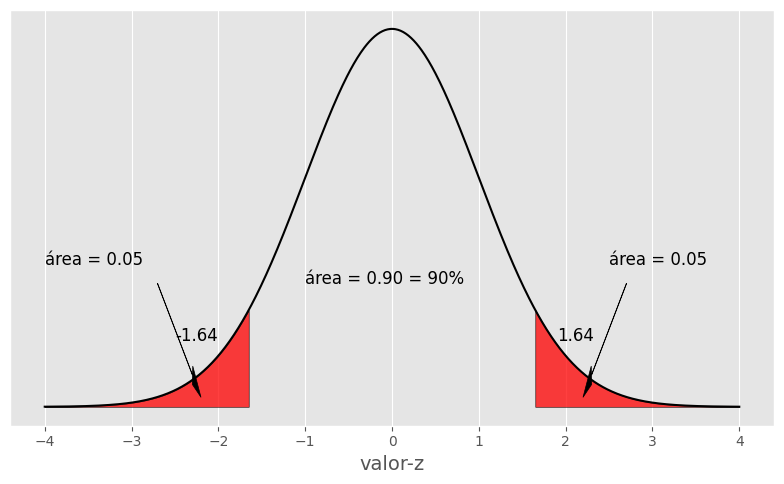

In [14]:
# Destaca simultaneamente as duas caudas de 5% da normal padrão.
mu = 0
sigma = 1
cut_a = 0.05
cut_b = 4

# PDF usada para comparar simultaneamente as duas caudas simétricas.
x = np.arange(-4, 4.01, 0.01)
yy = stats.norm.pdf(x, mu, sigma)

plt.figure()
plt.plot(x, yy, color="black")

# Destaca 5% em cada cauda e 90% na região central.
plt.fill_between(
    x=x,
    y1=yy,
    where=(x >= stats.norm.ppf(1 - 0.05)),
    color="red",
    edgecolor="black",
    alpha=0.75,
)

plt.fill_between(
    x=x,
    y1=yy,
    where=(x <= stats.norm.ppf(0.05)),
    color="red",
    edgecolor="black",
    alpha=0.75,
)

plt.text(2.5, 0.15, "área = 0.05")
plt.text(-1, 0.13, "área = 0.90 = 90%")
plt.text(-4, 0.15, "área = 0.05")

plt.text(1.9, 0.07, "1.64")
plt.text(-2.5, 0.07, "-1.64")

plt.arrow(
    2.7,
    0.13,
    -0.5,
    -0.12,
    length_includes_head=True,
    head_width=0.02,
    head_length=0.1,
    color="black",
)

plt.arrow(
    -2.7,
    0.13,
    0.5,
    -0.12,
    length_includes_head=True,
    head_width=0.02,
    head_length=0.1,
    color="black",
)

plt.xlabel("valor-z")
plt.yticks([])
plt.show()


### Padronização de uma Variável com Distribuição Normal  
Antes de aplicarmos o conceito de **normal padrão** a um conjunto de dados real, precisamos discutir a **padronização** de uma distribuição normal. Sabemos que uma distribuição normal é parametrizada por dois parâmetros — sua **média** $\mu \in \mathbb{R}$ e seu **desvio-padrão** $\sigma \in \mathbb{R}_{>0}$ — e escrevemos $X \sim \mathcal{N}(\mu,\sigma)$. Os valores desses parâmetros dependem da população e das métricas usadas para descrever suas características.

Para transformar quaisquer valores específicos de $\mu$ e $\sigma$, associados a uma variável aleatória $X$, em $\mu = 0$ e $\sigma = 1$, precisamos converter o valor $x$ em um **valor-$z$** aplicando a equação abaixo:
$$
z \;=\; \frac{x - \mu}{\sigma}.
$$

Como resultado, obtemos uma **distribuição normal padronizada** a partir de qualquer distribuição normal particular. Esse procedimento é essencial quando se deseja determinar **escores-$z$** ou qualquer **probabilidade** associada a um escore-$z$ (isto é, $P(z)$) consultando uma tabela. Veremos adiante que o **Python** é uma ferramenta tão poderosa que torna esse passo de padronização dispensável em muitos casos.

<img src="imgs/normalDIst_4.png" width="800">

### Distribuição Normal: dados de alturas

In [15]:
# Garante que o arquivo está disponível antes da leitura.
data_path = "../../dataset/weight-height.csv"

# Carrega a base e padroniza nomes de colunas em minúsculas.
students = pd.read_csv(data_path)

# Exibe as primeiras linhas para verificar a estrutura dos dados.
students.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [16]:
# Pré-processamento simples
students.columns = students.columns.str.lower()
students['gender'] = students['gender'].str.lower()
students['height'] = students['height'] * 2.54
students['weight'] = students['weight'] * 0.45359237
students.head()

,gender,height,weight
0,male,187.571423,109.721075
1,male,174.706036,73.622792
2,male,188.239668,96.497629
3,male,182.196685,99.809586
4,male,177.499761,93.598695


In [17]:
# Resumo estrutural do DataFrame (tipos e contagem de valores).
students.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gender  10000 non-null  object 
 1   height  10000 non-null  float64
 2   weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


O conjunto de dados **students** consiste em **10000 linhas**, cada uma representando um estudante, e **3 colunas**, cada uma correspondendo a uma variável/atributo daquele estudante. Essas variáveis autoexplicativas são: `[gender, height, weight]`.

Nesta seção, usaremos a variável **height** para exercitar o que discutimos até aqui.

Antes de aplicar probabilidades baseadas na distribuição normal, precisamos avaliar se a variável de interesse é **compatível** com uma aproximação normal. Se uma variável tem distribuição normal, então, para uma **amostra grande**, o **histograma** das observações tende a apresentar formato **aproximadamente em sino** (*bell-shaped*). Esse diagnóstico visual é útil, mas não prova normalidade; ele deve ser combinado com ferramentas como Q-Q plots e com o conhecimento substantivo sobre a variável.


In [18]:
# Medidas básicas para usar nos próximos gráficos e análises.
count_row = students.shape[0]  # número de linhas
count_col = students.shape[1]  # número de colunas
column_names = students.columns  # nomes das colunas

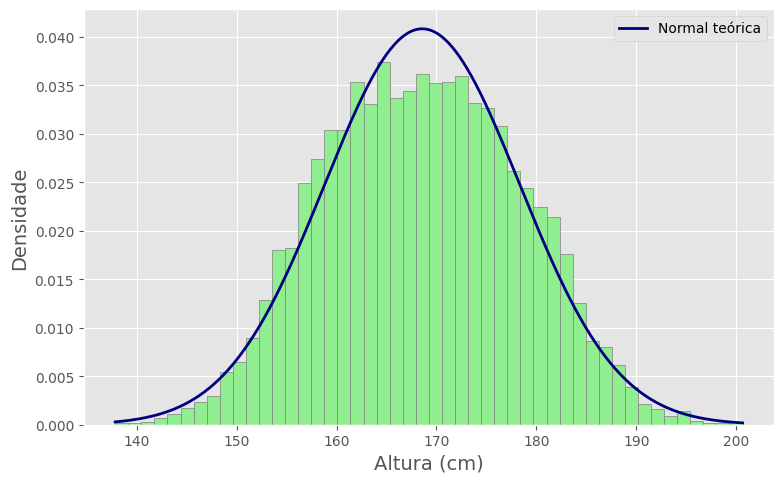

In [19]:
# Histograma para avaliar visualmente a forma da distribuição de alturas.
plt.figure()
plt.hist(students["height"], bins="fd", color="lightgreen", edgecolor="grey", density=True)
mu_all = students["height"].mean()
sigma_all = students["height"].std()
x_vals = np.linspace(students["height"].min(), students["height"].max(), 500)
normal_curve = stats.norm.pdf(x_vals, loc=mu_all, scale=sigma_all)
plt.plot(x_vals, normal_curve, color="navy", linewidth=2, label="Normal teórica")
plt.xlabel("Altura (cm)")
plt.ylabel("Densidade")
plt.legend()
plt.show()


Ao inspecionar o gráfico, temos uma primeira evidência de que a variável **height** pode ser aproximada por uma distribuição normal; porém, especialmente em **amostras pequenas**, identificar claramente o formato no histograma — em particular se é “em sino” — pode ser difícil. Assim, é recomendável uma técnica gráfica **mais sensível** para avaliar a normalidade. **Gráficos de probabilidade normal** fornecem essa técnica. A ideia é simples: **comparar** os valores observados da variável com os valores **esperados** para uma variável com distribuição normal. Mais precisamente, um gráfico de probabilidade normal plota os valores observados **versus** os **escores normais** esperados para uma variável com **distribuição normal padrão**. Se a variável for normalmente distribuída, o gráfico deve ser **aproximadamente linear** (isto é, cair aproximadamente sobre uma **reta**) (Weiss, 2010).

Ao usar um gráfico de probabilidade normal para avaliar a normalidade de uma variável, devemos lembrar de dois pontos:

1. A decisão sobre o quão “aproximadamente linear” é o gráfico é **subjetiva**; e  
2. Estamos usando apenas um **número limitado de observações** dessa variável para emitir um juízo sobre **todas** as possíveis observações.

Em **Python**, podemos empregar `statsmodels.graphics.gofplots.qqplot` (acessível via `sm.graphics.qqplot`) para gerar um Q–Q plot diretamente. O retorno é uma figura Matplotlib que podemos customizar para ajustar cores, transparência e a linha de referência contra a distribuição normal.


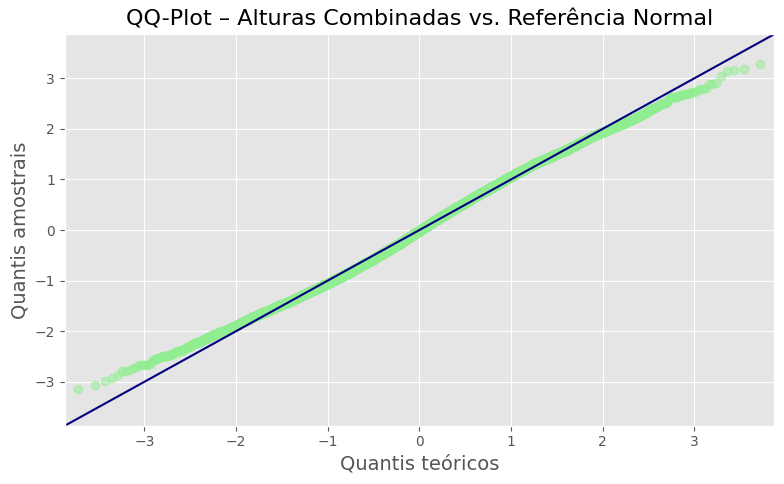

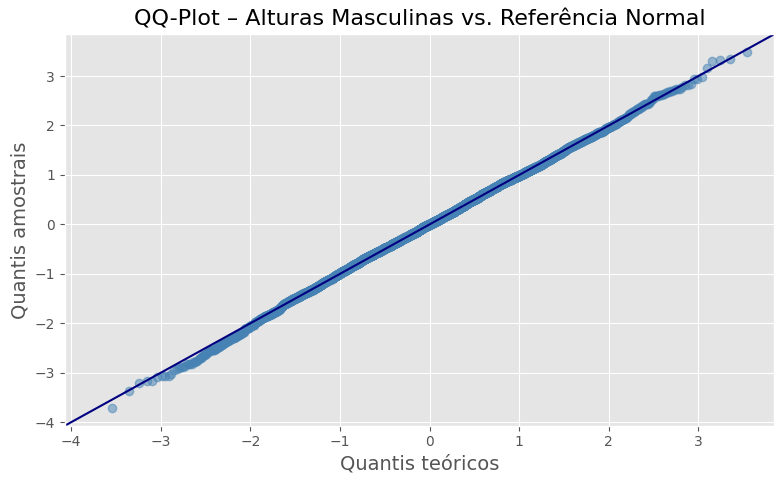

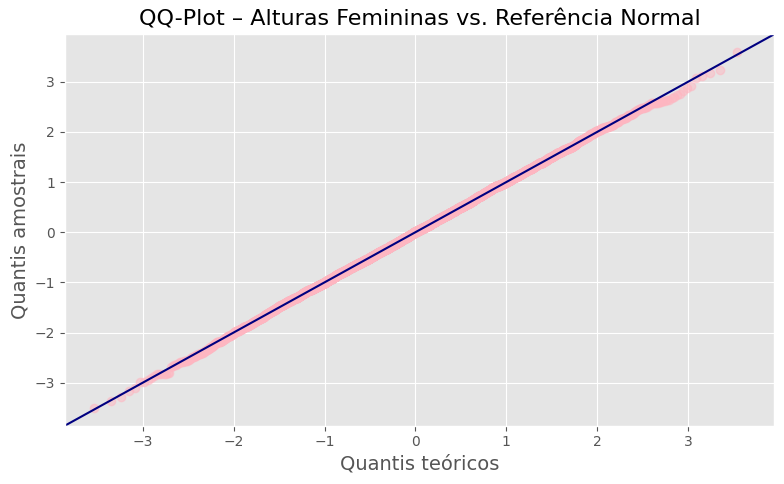

In [20]:
# Função utilitária para QQ-plots e análises por gênero na base de alturas.
import statsmodels.api as sm

# Função utilitária para construir QQ-plots contra a distribuição normal.
def plot_normal_qq(serie, titulo, cor):
    fig = sm.graphics.qqplot(
        serie,
        dist=stats.norm,
        fit=True,
        line="45",
    )
    fig.set_size_inches(8, 5)
    ax = fig.axes[0]
    pontos = ax.lines[0]
    pontos.set_markerfacecolor(cor)
    pontos.set_markeredgecolor(cor)
    pontos.set_alpha(0.5)
    ax.lines[1].set_color("navy")
    ax.set_title(titulo)
    ax.set_xlabel("Quantis teóricos")
    ax.set_ylabel("Quantis amostrais")
    plt.show()

## Subconjunto por gênero
males = students.loc[students["gender"] == "male", :].copy()
females = students.loc[students["gender"] == "female", :].copy()

# QQ-plot para todas as alturas combinadas.
plot_normal_qq(
    students['height'],
    "QQ-Plot – Alturas Combinadas vs. Referência Normal",
    cor = "lightgreen"
)

# QQ-plot para as alturas masculinas.
plot_normal_qq(
    males['height'],
    "QQ-Plot – Alturas Masculinas vs. Referência Normal",
    cor="steelblue"
)

# QQ-plot para as alturas femininas.
plot_normal_qq(
    females['height'],
    "QQ-Plot – Alturas Femininas vs. Referência Normal",
    cor="lightpink",
)


### Vídeo: O que é Quantile-Quantile Plots (QQ plots)?

Assista ao vídeo explicativo sobre a **QQ-Plot** neste [link](https://youtu.be/okjYjClSjOg?si=DxGD76jvZ_rgCYb4) ou visualize o vídeo diretamente no notebook abaixo:

[<img src="imgs/statquest_qqplot.jpg" width="400">](https://youtu.be/okjYjClSjOg?si=DxGD76jvZ_rgCYb4)

Ao inspecionar o Q-Q plot do conjunto combinado, vemos alguma divergência entre os quantis amostrais e os quantis teóricos nas caudas inferior e superior. Esse fato merece atenção porque pode indicar que uma única distribuição normal não representa igualmente bem todos os subgrupos presentes nos dados.

Uma possível explicação é a variável **gender**: é plausível que a altura média de homens e mulheres seja diferente. Para investigar essa hipótese, vamos traçar um histograma das alturas por gênero.


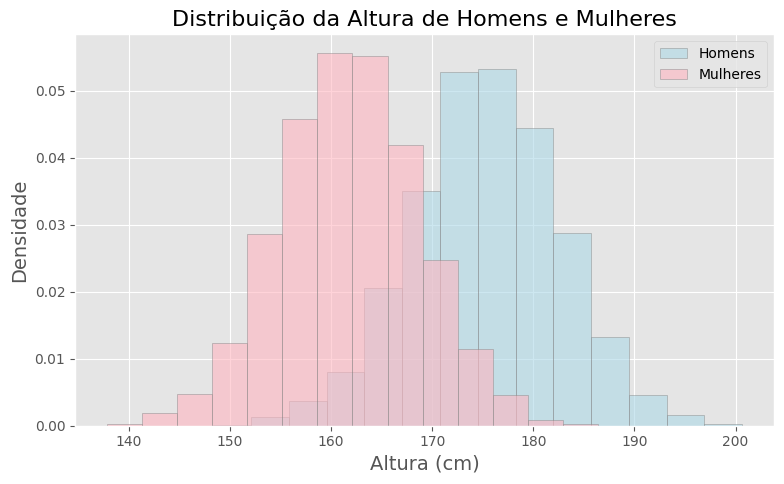

In [21]:
## gráfico por gênero
plt.figure()
plt.hist(
    males['height'],
    bins="sturges",
    density=True,
    color="lightblue",
    edgecolor="grey",
    alpha=0.6,
)
plt.hist(
    females['height'],
    bins="sturges",
    density=True,
    color="lightpink",
    edgecolor="grey",
    alpha=0.6,
)

plt.xlabel("Altura (cm)")
plt.ylabel("Densidade")
plt.title("Distribuição da Altura de Homens e Mulheres")
plt.legend(["Homens", "Mulheres"])
plt.show()


O histograma por gênero sugere que os dois grupos têm **centros diferentes**. Ao juntar homens e mulheres em um único grupo, a distribuição resultante pode apresentar caudas mais extensas ou uma forma menos compatível com uma única normal, porque estamos misturando subpopulações com médias distintas.

Para continuar os exercícios com uma aproximação normal mais defensável, consideraremos apenas a altura das alunas. Ainda assim, a hipótese de normalidade deve ser lida como uma **aproximação operacional**, apoiada por histogramas e Q-Q plots, não como uma propriedade garantida dos dados.


Antes de iniciar os exercícios, calculamos a **média amostral** $\bar{x}$ e o **desvio-padrão amostral** $s$ da variável de interesse. Em seguida, **padronizamos** a variável para obter escores-z com média aproximadamente $0$ e desvio-padrão aproximadamente $1$.

Como estamos trabalhando com uma amostra de alunas, usaremos `ddof=1` no desvio-padrão para alinhar o código à notação $s$.


In [22]:
# Alturas
height_mean = females["height"].mean()
height_sd = females["height"].std(ddof=1)

print(f"A variável height tem média de {height_mean:.2f} cm")
print(f"e desvio-padrão amostral de {height_sd:.2f} cm.")


A variável height tem média de 161.82 cm
e desvio-padrão amostral de 6.85 cm.


In [23]:
# transformação z (padronização, z-score)
height_z = (females["height"] - height_mean) / height_sd
print(f"A variável height padronizada tem média de {height_z.mean():.2f}")
print(f"e desvio-padrão amostral de {height_z.std(ddof=1):.2f}.")


A variável height padronizada tem média de 0.00
e desvio-padrão amostral de 1.00.


### Encontrando a área à esquerda de um **$z$-score** ou **$x$-score** especificado

**Questão 1**  
Qual é a probabilidade de que uma estudante escolhida aleatoriamente, do conjunto de dados, tenha **altura menor ou igual a 168 cm**? Isto é, estamos procurando
$$
P(X \le 168).
$$

Primeiro, calculamos a probabilidade para a variável **padronizada**. Portanto, precisamos transformar o valor de interesse (168 cm) em um **escore-$z$**:
$$
z \;=\; \frac{x - \mu}{\sigma}
\;=\; \frac{168 - 161.82}{6.85}
\;=\; 0.90.
$$

Em seguida, calculamos a **área à esquerda** do valor-$z$ obtido. Lembre-se de que a área sob a curva de uma variável normalmente distribuída pode ser calculada usando a função `norm.cdf` do módulo `scipy.stats`. A função é escrita como `norm.cdf(x, loc=0, scale=1)`. Para este cálculo específico, podemos aceitar os valores padrão dos argumentos.

In [24]:
# Calcula a probabilidade de uma aluna ter altura até 168 cm após padronizar.
x = 168  # altura em cm
x_z = (x - height_mean) / height_sd  # transformação z (padronização)
stats.norm.cdf(x_z)

np.float64(0.8165612440112708)

O cálculo produz:
$$
P(z \le 0.90) \approx 0.82.
$$

Agora faremos o mesmo cálculo, **mas** desta vez **pularemos a padronização**. Graças ao Python, não precisamos recorrer a tabelas: podemos simplesmente passar a **média amostral** $\bar{x}$ e o **desvio-padrão amostral** $s$ diretamente para `norm.cdf()`.

Em outras palavras, calculamos
$$
P(X \le 168) = \texttt{stats.norm.cdf}(168,\; \texttt{loc}=\bar{x},\; \texttt{scale}=s).
$$

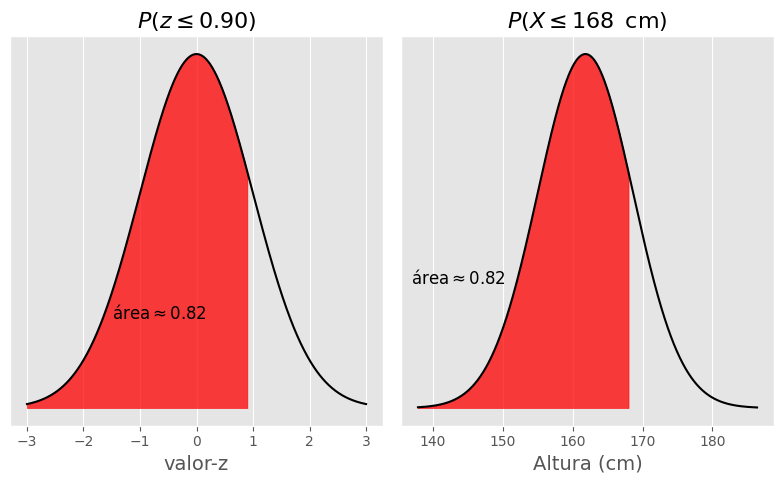

In [25]:
# Visualiza a área acumulada tanto na normal padrão quanto na distribuição original.
z_value = (x - height_mean) / height_sd
probability = stats.norm.cdf(z_value)

x_grid = np.arange(-3, 3.01, 0.01)
pdf_standard = stats.norm.pdf(x_grid)

fig, ax = plt.subplots(1, 2)
ax[0].plot(x_grid, pdf_standard, color="black")
ax[0].set_title(fr"$P(z \leq {z_value:.2f})$")
ax[0].set_yticks([])
ax[0].set_xlabel("valor-z")

ax[0].fill_between(
    x=x_grid,
    y1=pdf_standard,
    where=(x_grid <= z_value),
    color="red",
    alpha=0.75,
)

ax[0].text(
    -1.5,
    0.1,
    fr"$\text{{área}} \approx {probability:.2f}$",

)

x_vals = np.arange(min(females["height"]), max(females["height"]), 0.01)
pdf_sample = stats.norm.pdf(x_vals, height_mean, height_sd)
ax[1].plot(x_vals, pdf_sample, color="black")
ax[1].set_title(fr"$P(X \leq {x}\,\text{{ cm}})$")
ax[1].set_yticks([])
ax[1].set_xlabel("Altura (cm)")

ax[1].fill_between(
    x=x_vals,
    y1=pdf_sample,
    where=(x_vals <= x),
    color="red",
    alpha=0.75,
)
ax[1].text(
    height_mean - 25,
    max(pdf_sample) * 0.35,
    fr"$\text{{área}} \approx {probability:.2f}$",

)

plt.show()


### Encontrando a área à **direita** de um **$x$-score** especificado

**Questão 2**  
Qual é a probabilidade de que uma estudante escolhida aleatoriamente, do conjunto **students**, tenha **altura maior ou igual a 175 cm**? Estamos buscando
$$
P(X \ge 175).
$$
Para obter a **área à direita** do valor de interesse, usamos a **cauda superior** da distribuição normal. Em Python, isso equivale a calcular
$$
P(X \ge 175) \;=\; 1 - \texttt{norm.cdf}(175,\; \texttt{loc}=\bar{x},\; \texttt{scale}=s).
$$

> Dica: também é possível usar diretamente a função de sobrevivência: `stats.norm.sf(175, loc=height_mean, scale=height_sd)`, que já retorna a cauda superior.
>

**Resposta:**

$$
P(X \ge 175) \approx 0.027 \quad (\text{cerca de } 2.7\%).
$$

In [26]:
# Probabilidade de uma aluna ter altura maior ou igual a 175 cm (cauda superior).
x = 175  # altura em cm
1 - stats.norm.cdf(x, loc=height_mean, scale=height_sd)

np.float64(0.02714909144553357)

### Encontrando a área **entre dois** valores específicos de \(x\)

Para encontrar a área sob a curva em um intervalo $[a, b]$, usamos:
$$
P(a \le X \le b)
= \int_{a}^{b} f(x)\,dx
= P(X \le b) - P(X \le a).
$$

**Questão 3**  
Qual é a probabilidade de que uma estudante escolhida aleatoriamente, do conjunto de dados, tenha altura entre **155** e **165** cm, isto é,
$$
P(155 \le X \le 165)\,?
$$

**Resposta:**
$$
P(155 \le X \le 165) \approx 0.52 \quad (\text{cerca de } 52\%).
$$

In [27]:
# Probabilidade de a altura ficar no intervalo entre 155 cm e 165 cm.
x_lower = 155 # altura em cm
x_upper = 165 # altura em cm

cdf_upper = stats.norm.cdf(x_upper, loc=height_mean, scale=height_sd)
cdf_lower = stats.norm.cdf(x_lower, loc=height_mean, scale=height_sd)
cdf_upper - cdf_lower

np.float64(0.519123452968779)

**Questão 4**

Qual é a probabilidade de que uma estudante tenha altura entre 170 e 180 cm?

**Resposta:**
$$
P(170 \le X \le 180) \approx 0.112 \;\; (\text{cerca de } 11.2\%).
$$

In [28]:
# Probabilidade de a altura ficar no intervalo entre 170 cm e 180 cm.
x_lower = 170 # altura em cm
x_upper = 180 # altura em cm

cdf_upper = stats.norm.cdf(x_upper, loc=height_mean, scale=height_sd)
cdf_lower = stats.norm.cdf(x_lower, loc=height_mean, scale=height_sd)
cdf_upper - cdf_lower

np.float64(0.11219572536367983)

**Questão 5 - Encontrando $z_\alpha$**

Qual é a **altura** das alunas no nosso conjunto de dados que corresponde a uma **probabilidade de 0.60**? Em outras palavras: se escolhermos aleatoriamente \(n\) alunas do conjunto, **qual altura** divide a amostra em **60%** com altura **menor** e **40%** com altura **maior**? Procuramos, portanto:
$$
P(X < \, ? ) = 0.60.
$$

In [29]:
# Obtém o quantil z que deixa 60% da massa acumulada à esquerda na normal padrão.
z = stats.norm.ppf(0.6, loc=0, scale=1)
z

np.float64(0.2533471031357997)

Agora que já conhecemos o valor de $z$, podemos substituí-lo na equação anterior:



$$
z \;=\; \frac{x - \mu}{\sigma} \quad \text{ou} \quad
x = z\,\sigma + \mu \tag{1}
$$

$$
x = 0.253 \times 6.85 + 161.82 \tag{2}
$$

$$
x \approx 163.56 \tag{3}
$$

**Portanto**, a altura correspondente a uma probabilidade acumulada de 0.60 é aproximadamente **163.56 cm**.

In [30]:
# Converte o quantil z em altura real usando média e desvio padrão amostrais.
out = round(z * height_sd + height_mean, 2)
out

np.float64(163.56)

Sem surpresa, os valores coincidem:

$$
P(X < 163.56) = 0.60.
$$

Ou seja, aproximadamente **60% das alunas** têm altura **inferior a 163.56 cm**.

### Aplicações da distribuição Normal

As aplicações a seguir consolidam cinco usos da Normal, em ordem crescente de complexidade:

- aplicar a regra empírica dos desvios-padrão;
- comparar curvas normais com médias e variâncias diferentes;
- consultar probabilidades na Normal padrão;
- calcular probabilidades em uma Normal qualquer;
- obter parâmetros e probabilidades condicionais a partir de quantis.


In [31]:
# Regra aproximada dos dois desvios-padrão para uma população de pesos.
mu_peso = 70
sigma_peso = 10
intervalo_95_aprox = (mu_peso - 2 * sigma_peso, mu_peso + 2 * sigma_peso)
prob_exata_2dp = stats.norm.cdf(2) - stats.norm.cdf(-2)

print(f"Intervalo aproximado de 95%: {intervalo_95_aprox[0]} kg a {intervalo_95_aprox[1]} kg")
print(f"Área exata entre mu ± 2sigma na Normal: {prob_exata_2dp:.4f}")


Intervalo aproximado de 95%: 50 kg a 90 kg
Área exata entre mu ± 2sigma na Normal: 0.9545


### Comparação visual de média e variância em curvas normais

Para comparar curvas normais, mantenha separadas duas leituras:

- mudar $\mu$ desloca a curva horizontalmente;
- mudar $\sigma^2$ altera a dispersão, deixando a curva mais concentrada ou mais espalhada.

O gráfico abaixo replica essa ideia com três curvas normais.


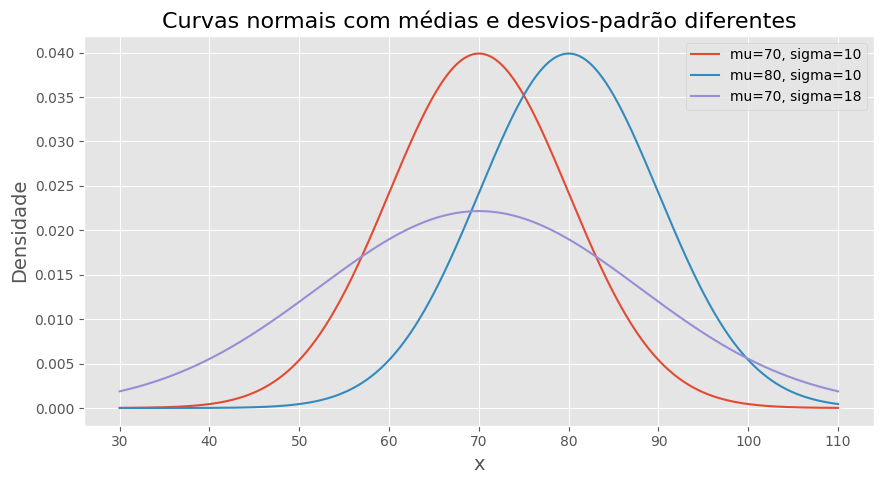

In [32]:
# Comparação visual de médias e variâncias em curvas normais.
x_norm = np.linspace(30, 110, 600)
curvas_normais = [
    (70, 10, "mu=70, sigma=10"),
    (80, 10, "mu=80, sigma=10"),
    (70, 18, "mu=70, sigma=18"),
]

plt.figure(figsize=(9, 5))
for mu, sigma, label in curvas_normais:
    plt.plot(x_norm, stats.norm.pdf(x_norm, loc=mu, scale=sigma), label=label)

plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Curvas normais com médias e desvios-padrão diferentes")
plt.legend()
plt.show()


In [33]:
# Probabilidade na Normal padrão e retorno de ação.
z_tabela = 0.83
print(f"P(Z < {z_tabela}) = {stats.norm.cdf(z_tabela):.4f}")

# Retorno de uma ação: X ~ N(20, 2^2); renda fixa = 17%.
mu_retorno = 20
sigma_retorno = 2
prob_supera_renda_fixa = stats.norm.sf(17, loc=mu_retorno, scale=sigma_retorno)
print(f"P(X > 17) = {prob_supera_renda_fixa:.4f}")


P(Z < 0.83) = 0.7967
P(X > 17) = 0.9332


### Determinação de $\mu$ e $\sigma$ a partir de quantis

Considere uma variável normal com

$$
P(X\le 70)=0.75
\qquad\text{e}\qquad
P(X\le 50)=0.25.
$$

Como os quantis 0.25 e 0.75 da Normal padrão são simétricos, resolvemos o sistema

$$
\frac{70-\mu}{\sigma}=z_{0.75},
\qquad
\frac{50-\mu}{\sigma}=z_{0.25}.
$$

Depois calculamos a probabilidade condicional

$$
P(X>85\mid X>75)=\frac{P(X>85)}{P(X>75)}.
$$


In [34]:
# Estimação de mu e sigma por dois quantis e probabilidade condicional.
x_q75 = 70
x_q25 = 50
z_q75 = stats.norm.ppf(0.75)
z_q25 = stats.norm.ppf(0.25)

# Cálculo computacional com quantis exatos do SciPy.
sigma_429 = (x_q75 - x_q25) / (z_q75 - z_q25)
mu_429 = x_q75 - z_q75 * sigma_429
rv_429 = stats.norm(loc=mu_429, scale=sigma_429)
prob_cond_429 = rv_429.sf(85) / rv_429.sf(75)

# Aproximação compatível com uma tabela arredondada.
mu_429_tabela = 60
sigma_429_tabela = 14.9
rv_429_tabela = stats.norm(loc=mu_429_tabela, scale=sigma_429_tabela)
prob_cond_429_tabela = rv_429_tabela.sf(85) / rv_429_tabela.sf(75)

print("Cálculo com quantis exatos do SciPy")
print(f"z_0.75 = {z_q75:.4f}")
print(f"z_0.25 = {z_q25:.4f}")
print(f"mu = {mu_429:.2f}")
print(f"sigma = {sigma_429:.2f}")
print(f"P(X > 85 | X > 75) = {prob_cond_429:.3f}")
print()
print("Aproximação com arredondamentos de tabela")
print(f"mu = {mu_429_tabela:.2f}")
print(f"sigma = {sigma_429_tabela:.2f}")
print(f"P(X > 85 | X > 75) = {prob_cond_429_tabela:.3f}")


Cálculo com quantis exatos do SciPy
z_0.75 = 0.6745
z_0.25 = -0.6745
mu = 60.00
sigma = 14.83
P(X > 85 | X > 75) = 0.294

Aproximação com arredondamentos de tabela
mu = 60.00
sigma = 14.90
P(X > 85 | X > 75) = 0.297


### Exercício 1 - Estoque de camisas

A circunferência do pescoço dos clientes segue

$$
X\sim N(15.25, 0.50^2).
$$

Os tamanhos de colarinho são 15.00 (PP), 15.50 (P), 16.00 (M), 16.50 (G) e 17.00 (GG). Com folga mínima de 0.75 polegada entre colarinho e pescoço, cada tamanho atende pescoços até `colarinho - 0.75`. Portanto, os percentuais são calculados por intervalos sucessivos da Normal.


In [35]:
# Percentuais por tamanho de camisa.
mu_pescoco = 15.25
sigma_pescoco = 0.50
rv_pescoco = stats.norm(loc=mu_pescoco, scale=sigma_pescoco)

colarinho = {
    "PP (15.00)": 15.00,
    "P (15.50)": 15.50,
    "M (16.00)": 16.00,
    "G (16.50)": 16.50,
    "GG (17.00)": 17.00,
}
limites_folga = {tam: valor - 0.75 for tam, valor in colarinho.items()}

limite_anterior = -np.inf
percentuais = []
for tamanho, limite in limites_folga.items():
    prob = rv_pescoco.cdf(limite) - rv_pescoco.cdf(limite_anterior)
    percentuais.append((tamanho, limite_anterior, limite, prob))
    limite_anterior = limite

# Pessoas acima do limite do GG não são atendidas pelos tamanhos listados.
prob_acima_gg = rv_pescoco.sf(limite_anterior)

camisas = pd.DataFrame(
    percentuais,
    columns=["tamanho", "limite_inferior_pescoco", "limite_superior_pescoco", "proporcao"],
)
camisas["percentual"] = 100 * camisas["proporcao"]
camisas


,tamanho,limite_inferior_pescoco,limite_superior_pescoco,proporcao,percentual
0,PP (15.00),-inf,14.25,0.022750,2.275013
1,P (15.50),14.25,14.75,0.135905,13.590512
2,M (16.00),14.75,15.25,0.341345,34.134475
3,G (16.50),15.25,15.75,0.341345,34.134475
4,GG (17.00),15.75,16.25,0.135905,13.590512


In [36]:
print(f"Soma dos percentuais listados = {camisas['percentual'].sum():.2f}%")
print(f"Percentual acima do GG = {100 * prob_acima_gg:.2f}%")
print(f"Total = {camisas['percentual'].sum() + 100 * prob_acima_gg:.2f}%")


Soma dos percentuais listados = 97.72%
Percentual acima do GG = 2.28%
Total = 100.00%


### Exercício 2 - Casos mistos com componente contínuo

Nesta seção, mantemos apenas os componentes contínuos ou diretamente relacionados a variáveis aleatórias contínuas. Partes discretas pertencem ao notebook de variáveis aleatórias discretas.

**Conceitos probabilísticos.** O desvio-padrão é sempre não negativo porque $DP(X)=\sqrt{Var(X)}\ge 0$. Para uma Normal, cerca de 68% dos valores ficam entre $\mu-\sigma$ e $\mu+\sigma$.

**Alternativas de aplicação financeira.** A alternativa contínua tem retorno $X\sim N(15, 2^2)$. Logo, $E(X)=15$ e $Var(X)=4$. A alternativa discreta deve ser tratada no notebook de variáveis aleatórias discretas.


In [37]:
# verificação numérica da regra dos 68%.
area_1dp = stats.norm.cdf(1) - stats.norm.cdf(-1)
print(f"P(mu - sigma < X < mu + sigma) = {area_1dp:.4f}")

# componente contínuo da alternativa A.
retorno_A = stats.norm(loc=15, scale=2)
print("Alternativa A: E(X) = 15%")
print("Alternativa A: Var(X) = 2^2 = 4")
print(f"P(X > 17%) = {retorno_A.sf(17):.4f}")


P(mu - sigma < X < mu + sigma) = 0.6827
Alternativa A: E(X) = 15%
Alternativa A: Var(X) = 2^2 = 4
P(X > 17%) = 0.1587


### Exercício 3 - Altura de jogadores de basquetebol

Admita que a altura $X$ dos jogadores, em centímetros, segue

$$
X\sim N(\mu,20^2),
$$

com

$$
P(X>200)=0.40.
$$

Então $P(X\le 200)=0.60$, e usamos o quantil $z_{0.60}$ para determinar $\mu$.

In [38]:
# Determinação da média e probabilidade abaixo de 1.80 m.
sigma_jogadores = 20
x_200 = 200
z_060 = stats.norm.ppf(0.60)
mu_jogadores = x_200 - z_060 * sigma_jogadores
rv_jogadores = stats.norm(loc=mu_jogadores, scale=sigma_jogadores)
prob_menor_180 = rv_jogadores.cdf(180)

print(f"z_0.60 = {z_060:.3f}")
print(f"mu = {mu_jogadores:.1f} cm")
print(f"P(X < 180) = {prob_menor_180:.4f}")


z_0.60 = 0.253
mu = 194.9 cm
P(X < 180) = 0.2276


### Exercício 4 - Teste amostral para venda de fluido

Em condições normais, o conteúdo de uma substância $S$ no fluido $F$ segue

$$
X\sim N(87, 2^2).
$$

A compra ocorre se $82\le X\le 92$. Em uma remessa de 100 barris independentes, a probabilidade de pelo menos um barril ser rejeitado é o complemento da probabilidade de todos serem comprados.

In [39]:
# Probabilidade de compra e rejeição em 100 barris.
rv_fluido = stats.norm(loc=87, scale=2)
prob_compra = rv_fluido.cdf(92) - rv_fluido.cdf(82)
prob_pelo_menos_um_rejeitado = 1 - prob_compra**100

print(f"P(82 <= X <= 92) = {prob_compra:.4f}")
print(f"P(pelo menos um rejeitado em 100) = {prob_pelo_menos_um_rejeitado:.4f}")


P(82 <= X <= 92) = 0.9876
P(pelo menos um rejeitado em 100) = 0.7134


## A Distribuição Uniforme Contínua

A [distribuição Uniforme](https://en.wikipedia.org/wiki/Uniform_distribution_(continuous)) é uma das distribuições contínuas mais simples e desempenha um papel importante na estatística, pois modela situações em que **intervalos de mesmo comprimento** dentro de $[a,b]$ têm a mesma probabilidade. A variável aleatória contínua $X$ é dita uniformemente distribuída, ou possuir **distribuição retangular**, no intervalo $[a,b]$. Escrevemos $X \sim U(a,b)$, se sua função densidade de probabilidade for igual a $f(x) = \dfrac{1}{b-a},\ x \in [a,b]$ e $0$ em outros casos (Lovric 2011).

$$
f(x) =
\begin{cases}
\dfrac{1}{b-a}, & \text{quando } a \le x \le b \\
0, & \text{quando } x < a \text{ ou } x > b
\end{cases}
$$

A figura abaixo mostra uma distribuição uniforme contínua $X \sim U(-2,\, 0.8)$. A densidade é constante e igual a $\dfrac{1}{0.8-(-2)}=\dfrac{1}{2.8} \approx 0.36$ dentro do intervalo $[-2, 0.8]$ e igual a $0$ fora dele.


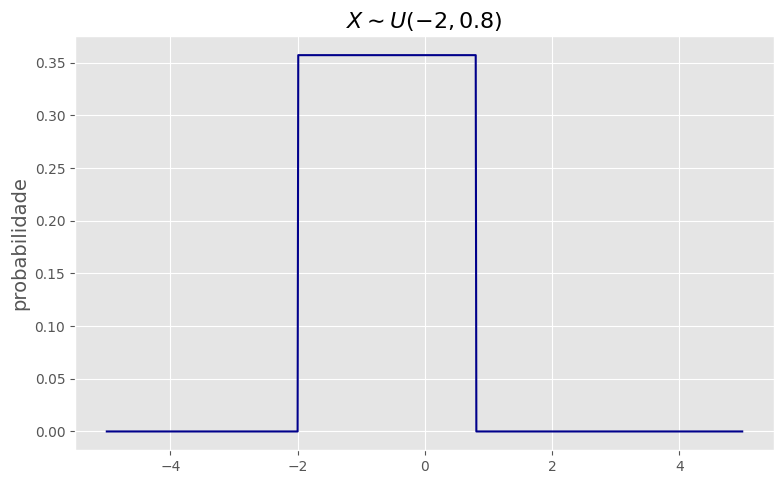

In [40]:
# PDF da uniforme contínua em [-2, 0.8] para ilustrar a densidade constante.
a = -2
b = 0.8
x = np.arange(-5, 5, 0.01)

plt.figure()
plt.plot(x, stats.uniform.pdf(x, loc=a, scale=b - a), color="darkblue")
plt.title("$X \\sim U(-2, 0.8)$")
plt.ylabel("probabilidade")

plt.show()

A média e a mediana são dadas por

$$
\mu = E(X)=\dfrac{a + b}{2}.
$$

A variância da uniforme contínua é

$$
Var(X)=\frac{(b-a)^2}{12},
\qquad
DP(X)=\sqrt{Var(X)}.
$$

A função de distribuição acumulada é mostrada abaixo e dada pela equação:

$$
F(x) =
\begin{cases}
0, & \text{para } x < a \\
\dfrac{x - a}{b - a}, & \text{para } x \in [a, b) \\
1, & \text{para } x \ge b
\end{cases}
$$


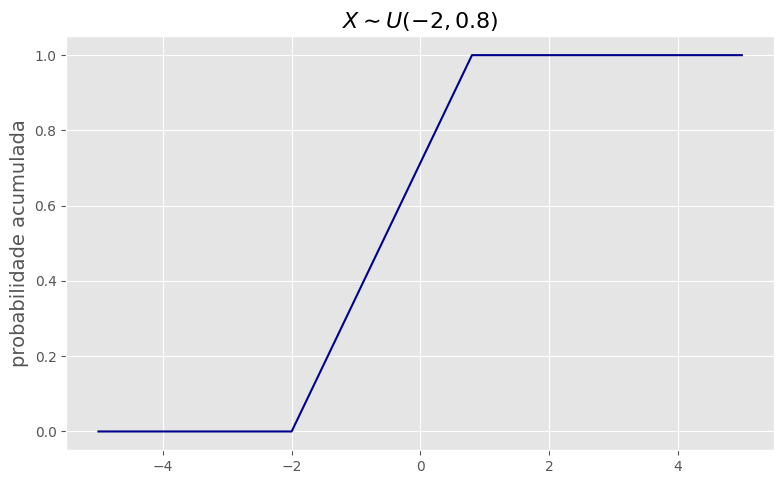

In [41]:
# CDF correspondente da uniforme contínua em [-2, 0.8].
plt.figure()
plt.plot(x, stats.uniform.cdf(x, loc=a, scale=b - a), color="darkblue")
plt.title("$X \\sim U(-2, 0.8)$")
plt.ylabel("probabilidade acumulada")

plt.show()

O Python fornece acesso à distribuição uniforme dentro do pacote `scipy.stats` por meio das funções `uniform.pdf()`, `uniform.cdf()`, `uniform.ppf()` e `uniform.rvs()`.  
Aplique a função `help()` nessas funções para obter mais informações ou consulte a documentação.

A função `uniform.rvs()` gera valores aleatórios (amostras) da distribuição uniforme e é escrita como  
`uniform.rvs(loc=a, scale=b-a, size=n)`.  
Em `scipy.stats.uniform`, o argumento `loc` representa o limite inferior $a$ e `scale` representa a largura do intervalo, isto é, $b-a$. Portanto, `scale` **não** é o desvio-padrão da distribuição uniforme.


In [42]:
# Amostra 40 valores uniformes em [0, 1] para exemplificar a função rvs.
stats.uniform.rvs(loc=0, scale=1, size=40, random_state=rng)

array([0.77395605, 0.43887844, 0.85859792, 0.69736803, 0.09417735,
       0.97562235, 0.7611397 , 0.78606431, 0.12811363, 0.45038594,
       0.37079802, 0.92676499, 0.64386512, 0.82276161, 0.4434142 ,
       0.22723872, 0.55458479, 0.06381726, 0.82763117, 0.6316644 ,
       0.75808774, 0.35452597, 0.97069802, 0.89312112, 0.7783835 ,
       0.19463871, 0.466721  , 0.04380377, 0.15428949, 0.68304895,
       0.74476216, 0.96750973, 0.32582536, 0.37045971, 0.46955581,
       0.18947136, 0.12992151, 0.47570493, 0.22690935, 0.66981399])

Podemos aproximar a função densidade de probabilidade para $X \sim U(-2,\, 0.8)$ usando a função `uniform.rvs()` e representar os resultados em um histograma.

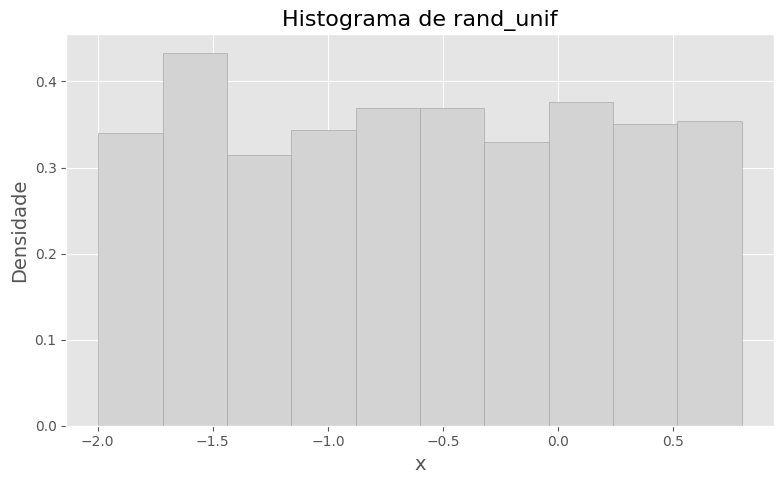

In [43]:
# Gera 1000 observações uniformes em [-2, 0.8] e inspeciona a densidade com um histograma.
rand_unif = stats.uniform.rvs(loc=-2, scale=2.8, size=1000, random_state=rng)
plt.figure()
plt.hist(rand_unif, density=True, color="lightgrey", edgecolor="darkgrey")
plt.xlabel("x")
plt.ylabel("Densidade")
plt.title("Histograma de rand_unif")
plt.show()


Além disso, podemos traçar tanto o histograma de densidade mostrado acima quanto a distribuição de probabilidade uniforme para o intervalo $[-2,\,0.8]$, aplicando a função `uniform.pdf()`.

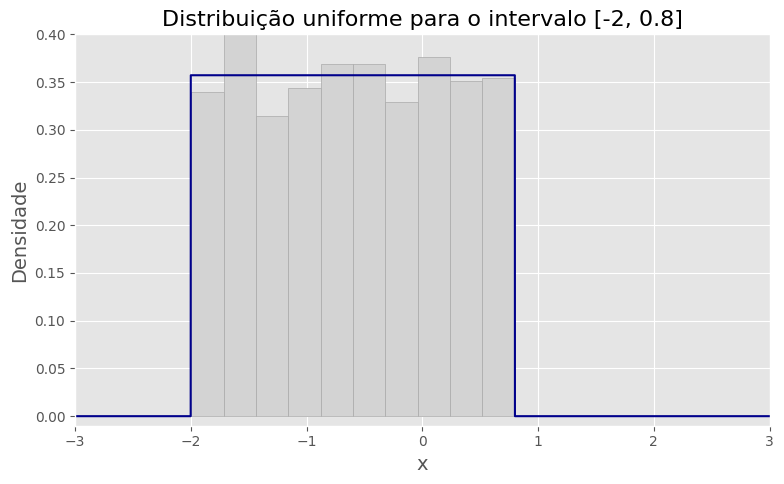

In [44]:
# Compara a amostra simulada com a densidade uniforme teórica no mesmo gráfico.
a = -2
b = 0.8

plt.figure()
plt.hist(rand_unif, density=True, color="lightgrey", edgecolor="darkgrey")
plt.title("Distribuição uniforme para o intervalo [-2, 0.8]")

x = np.arange(-5, 5, 0.001)
plt.plot(x, stats.uniform.pdf(x, loc=a, scale=2.8), color="darkblue")

plt.ylim(-0.01, 0.4)
plt.xlim(-3, 3)

plt.xlabel("x")
plt.ylabel("Densidade")
plt.show()


A figura indica que nossas 1.000 amostras geradas aleatoriamente a partir de uma distribuição uniforme (gráfico de histograma) aproximam bem a distribuição de probabilidade uniforme  
$X \sim U(-2,\, 0.8)$ (gráfico de linha).

Além disso, podemos usar a função `uniform.cdf()` para calcular a área sob a curva para um determinado valor limite ou usar a função `uniform.ppf()` para retornar um valor limite para uma probabilidade específica.

In [45]:
# Parâmetros da uniforme contínua.
unif_lower = -3
unif_upper = 5.5
scale = unif_upper - unif_lower  # 8.5

# Probabilidade de X ser ≤ o limite 4
area_ate_4 = stats.uniform.cdf(4, loc=unif_lower, scale=scale)

# Valor limite correspondente à probabilidade acumulada 0.6
valor_para_60 = stats.uniform.ppf(0.6, loc=unif_lower, scale=scale)

print(f"P(X ≤ 4) = {area_ate_4:.3f}")
print(f"Valor que deixa 60% à esquerda = {valor_para_60:.3f}")


P(X ≤ 4) = 0.824
Valor que deixa 60% à esquerda = 2.100


### Aplicações da uniforme contínua

A uniforme contínua pode modelar erros de arredondamento e posições angulares quando intervalos de mesmo comprimento são igualmente prováveis.

Para o erro de arredondamento,

$$
X\sim U(-0.5, 0.5).
$$

Como a distribuição é simétrica em torno de zero, $E(X)=0$. Além disso,

$$
Var(X)=\frac{(0.5-(-0.5))^2}{12}=\frac{1}{12},
\qquad DP(X)\approx 0.289.
$$

Como $E(X)=0$, o coeficiente de variação não é definido.


In [46]:
# Erro de arredondamento.
round_lower = -0.5
round_upper = 0.5
round_scale = round_upper - round_lower
rv_round = stats.uniform(loc=round_lower, scale=round_scale)

prob_abs_menor_02 = rv_round.cdf(0.2) - rv_round.cdf(-0.2)
media_round = (round_lower + round_upper) / 2
var_round = round_scale**2 / 12
dp_round = np.sqrt(var_round)

print(f"P(|X| < 0.2) = {prob_abs_menor_02:.4f}")
print(f"E(X) = {media_round:.1f}")
print(f"Var(X) = {var_round:.4f}")
print(f"DP(X) = {dp_round:.3f}")
print("CV(X) não é definido, pois E(X)=0.")


P(|X| < 0.2) = 0.4000
E(X) = 0.0
Var(X) = 0.0833
DP(X) = 0.289
CV(X) não é definido, pois E(X)=0.


### Ponteiro de segundos

Se $X$ é o ângulo, em graus, formado pelo ponteiro dos segundos de um relógio com a vertical do número 12, então

$$
X\sim U(0, 360).
$$

A média é $180$ graus e a variância é $360^2/12=10800$.

In [47]:
# Ponteiro de segundos.
angle_lower = 0
angle_upper = 360
angle_scale = angle_upper - angle_lower
angle_mean = (angle_lower + angle_upper) / 2
angle_var = angle_scale**2 / 12
angle_sd = np.sqrt(angle_var)

print(f"E(X) = {angle_mean:.1f} graus")
print(f"Var(X) = {angle_var:.1f}")
print(f"DP(X) = {angle_sd:.2f} graus")


E(X) = 180.0 graus
Var(X) = 10800.0
DP(X) = 103.92 graus


### Exercício 5 - Uniforme contínua

Considere a distribuição de probabilidade uniforme dada por $X \sim U(-3, 5.5)$.

**Pergunta 1**  
Qual é a média, $\mu$, para a distribuição uniforme dada?

In [48]:
# Calcula a média teórica de U(-3, 5.5).
unif_mean = (-3 + 5.5) / 2
unif_mean

1.25

 A média, $\mu$, para a distribuição de probabilidade uniforme dada por
$X \sim U(-3, 5.5)$ é 1.25.

**Pergunta 2**  
Qual é o valor de $x$ correspondente ao valor que divide a distribuição uniforme dada em duas partes iguais, ou escrito de forma mais formal $P(X < \, ?)=0.5$?

In [49]:
# Calcula o percentil mediano (50%) para a uniforme U(-3, 5.5).
px_05 = stats.uniform.ppf(0.5, loc=-3, scale=8.5)
px_05

np.float64(1.25)

Como esperado para uma distribuição uniforme simétrica no intervalo, o valor de $x$ que divide a distribuição uniforme em duas partes iguais é 1.25 e, portanto, é igual a $\mu$.

**Pergunta 3**  
Dado que a distribuição acima descreve um fenômeno físico. Se fizermos uma medição desse processo físico que governa o fenômeno, qual é a probabilidade de medir um valor $\ge 4$, ou escrito de forma mais formal $P(X \ge 4)$?

Na distribuição uniforme contínua, **intervalos de mesmo comprimento** dentro de $[-3, 5.5]$ têm a mesma probabilidade. Valores pontuais individuais continuam tendo probabilidade zero, como ocorre em qualquer variável aleatória contínua.

Resolveremos essa questão de duas maneiras, numericamente e analiticamente. Primeiro, para resolver a questão numericamente, precisamos conduzir um experimento. Repetiremos nossa medição por um grande número de vezes e, em seguida, contaremos o número de vezes em que registramos um valor $\ge 4$. Graças ao gerador de números aleatórios integrado (`uniform.rvs()` para dados uniformemente distribuídos), a tarefa de repetição é muito fácil; no entanto, em aplicações do mundo real, muitas vezes há apenas um número limitado de medições disponíveis.


In [50]:
# Simula medições uniformes e calcula a fração que atinge pelo menos o limiar 4.
measurements = stats.uniform.rvs(
    loc=-3, scale=8.5, size=10_000, random_state=rng
)  # realiza 10.000 medições
count_above = (measurements >= 4).sum()  # conta valores >= 4
count_above / len(measurements)  # calcula a proporção de valores >= 4


np.float64(0.1735)

Os resultados mostram que aproximadamente 17.35% das medições produzem valores $\ge 4$.

Em segundo lugar, para resolver a questão analiticamente, fazemos uso da função de densidade de probabilidade acumulada, que é implementada em Python para distribuições uniformes pela função `uniform.cdf()`. Certifique-se de definir $1 - \text{uniform.cdf()}$ para calcular o resultado para a cauda superior, já que estamos procurando a probabilidade de medir valores $\ge 4$, portanto estamos interessados na área sob a curva à direita do valor de $x=4$.

In [51]:
# Probabilidade teórica de observar valores acima de 4 sob U(-3, 5.5).
result = 1 - stats.uniform.cdf(4, loc=-3, scale=8.5)
result

np.float64(0.17647058823529416)

A abordagem analítica produz um resultado de 0.1764 ou, em outras palavras, com uma probabilidade de 17.64% obtemos valores $\ge 4$, portanto $P(X \ge 4) \approx 0.18$.

As duas abordagens produzem resultados próximos, como esperado quando o número de simulações é grande. No entanto, esteja ciente de que o resultado da abordagem numérica é uma **aproximação do resultado analítico**. Tenha em mente que a qualidade de tal aproximação é muito sensível ao número de variáveis aleatórias que constituem a amostra, no nosso caso o número de medições.

## Distribuição Exponencial

A **distribuição exponencial** descreve o tempo entre eventos em um **processo pontual de Poisson**, ou seja, um processo no qual os eventos ocorrem continuamente e independentemente a uma taxa média constante.  
Ela possui um parâmetro $\lambda$, chamado **parâmetro de taxa**, e sua equação é descrita como:

$$
f(x;\lambda) =
\begin{cases}
\lambda e^{-\lambda x}, & x \ge 0, \\
0, & x < 0.
\end{cases}
$$

> Eventos raros ocorrem com uma certa taxa por unidade de tempo. Não há “memória” de eventos anteriores; isto é, essa taxa é independente do tempo. Um processo que gera tais eventos é chamado de **processo de Poisson**. A ocorrência de um evento raro nesse contexto é chamada de **chegada**.


Podemos gerar uma variável aleatória exponencialmente distribuída usando o método `expon.rvs()` do módulo `scipy.stats`. Para a exponencial em `scipy.stats`, o argumento `scale` representa a média da distribuição e corresponde a $1/\lambda$.

Assim, se a taxa é $\lambda = 0.2$, então `scale = 1/lambda = 5`. O argumento `loc` desloca o início da distribuição; nesta aula manteremos `loc=0`, pois a exponencial padrão modela tempos ou distâncias não negativos. O argumento `size` define o número de observações simuladas. Para manter a reprodutibilidade, usamos `random_state`.


### Probabilidades e quantis na distribuição exponencial

Assim como fizemos com a normal e a uniforme, também podemos calcular probabilidades acumuladas, caudas superiores e quantis da distribuição exponencial.

Se $X \sim \text{Exponencial}(\lambda)$, então:

$$
F(x) = P(X \le x) = 1 - e^{-\lambda x}, \quad x \ge 0.
$$

A cauda superior, também chamada de função de sobrevivência, é:

$$
P(X > x) = 1 - F(x) = e^{-\lambda x}.
$$

No cálculo abaixo, usamos $\lambda = 0.2$, isto é, tempo médio esperado $1/\lambda = 5$ unidades de tempo.


In [52]:
# Probabilidades e quantis para X ~ Exponencial(lambda = 0.2)
lam = 0.2
rv_exp = stats.expon(loc=0, scale=1 / lam)

x0 = 10
prob_ate_x0 = rv_exp.cdf(x0)
prob_acima_x0 = rv_exp.sf(x0)
mediana_exp = rv_exp.ppf(0.5)
percentil_90_exp = rv_exp.ppf(0.9)

print(f"P(X <= {x0}) = {prob_ate_x0:.3f}")
print(f"P(X > {x0}) = {prob_acima_x0:.3f}")
print(f"Mediana = {mediana_exp:.3f}")
print(f"Percentil 90 = {percentil_90_exp:.3f}")


P(X <= 10) = 0.865
P(X > 10) = 0.135
Mediana = 3.466
Percentil 90 = 11.513


### Média e variância da distribuição exponencial

Se $X$ tem distribuição exponencial com taxa $\lambda>0$, então

$$
E(X)=\frac{1}{\lambda},
\qquad
Var(X)=\frac{1}{\lambda^2},
\qquad
DP(X)=\frac{1}{\lambda}.
$$

No `scipy.stats`, usamos `scale=1/lambda`, que coincide com a média e o desvio-padrão da exponencial.

In [53]:
# Média, variância e desvio-padrão para X ~ Exponencial(lambda = 0.2).
lam = 0.2
rv_exp_momentos = stats.expon(loc=0, scale=1 / lam)

print(f"E(X) teórico = {1 / lam:.2f}")
print(f"Var(X) teórica = {1 / lam**2:.2f}")
print(f"DP(X) teórico = {1 / lam:.2f}")
print(f"Média via scipy = {rv_exp_momentos.mean():.2f}")
print(f"Variância via scipy = {rv_exp_momentos.var():.2f}")


E(X) teórico = 5.00
Var(X) teórica = 25.00
DP(X) teórico = 5.00
Média via scipy = 5.00
Variância via scipy = 25.00


### Tempo de vida de lâmpadas

O tempo de vida de uma lâmpada segue distribuição exponencial com média de 1000 horas. Logo,

$$
\lambda=\frac{1}{1000}=0.001.
$$

A proporção que queima antes de 1000 horas é

$$
P(T\le 1000)=1-e^{-1}\approx 0.632.
$$

O tempo até 90% das lâmpadas queimarem é o quantil de ordem 0.90:

$$
1-e^{-0.001t}=0.9
\Rightarrow t=-\frac{\ln(0.1)}{0.001}\approx 2303\text{ horas}.
$$

In [54]:
# Tempo de vida de lâmpadas.
media_lampadas = 1000
lam_lampadas = 1 / media_lampadas
rv_lampadas = stats.expon(loc=0, scale=media_lampadas)

prob_queima_antes_1000 = rv_lampadas.cdf(1000)
tempo_90_queimadas = rv_lampadas.ppf(0.90)

print(f"lambda = {lam_lampadas:.4f}")
print(f"P(T <= 1000) = {prob_queima_antes_1000:.3f}")
print(f"Percentil 90 = {tempo_90_queimadas:.0f} horas")


lambda = 0.0010
P(T <= 1000) = 0.632
Percentil 90 = 2303 horas


### Exercício 6 - Tempo de atendimento em loja

O tempo de atendimento segue distribuição exponencial com média de 15 minutos. Portanto,

$$
\lambda=\frac{1}{15}.
$$

Se a pergunta for atendimento de **pelo menos 30 minutos**, então

$$
P(X\ge 30)=e^{-30/15}=e^{-2}\approx 0.1353.
$$

A resposta $0.8647$ corresponde a uma pergunta diferente: atendimento de **no máximo 30 minutos**, isto é, $P(X\le 30)=1-e^{-2}$. O notebook registra os dois valores para explicitar a diferença entre cauda superior e probabilidade acumulada.

Para encontrar $c$ tal que $P(X\le c)=0.98$:

$$
c=-15\ln(0.02)\approx 58.68\text{ minutos}.
$$


In [55]:
# Tempo de atendimento em loja.
media_atendimento = 15
rv_atendimento = stats.expon(loc=0, scale=media_atendimento)

prob_pelo_menos_30 = rv_atendimento.sf(30)
prob_no_maximo_30 = rv_atendimento.cdf(30)
c_98 = rv_atendimento.ppf(0.98)

print(f"P(X >= 30) = {prob_pelo_menos_30:.4f}")
print(f"P(X <= 30) = {prob_no_maximo_30:.4f}")
print(f"c tal que P(X <= c)=0.98: {c_98:.2f} minutos")


P(X >= 30) = 0.1353
P(X <= 30) = 0.8647
c tal que P(X <= c)=0.98: 58.68 minutos


In [56]:
# Gera uma amostra exponencial com taxa 0.2 para usar nos gráficos comparativos.
lam = 0.2
N = 100
rvE = stats.expon(loc=0, scale=1/lam)
es = rvE.rvs(N, random_state=rng)
print(es[:10].round(3))

[12.37   1.858  9.774  3.316  6.086  8.686  0.943  2.395  2.818  0.709]


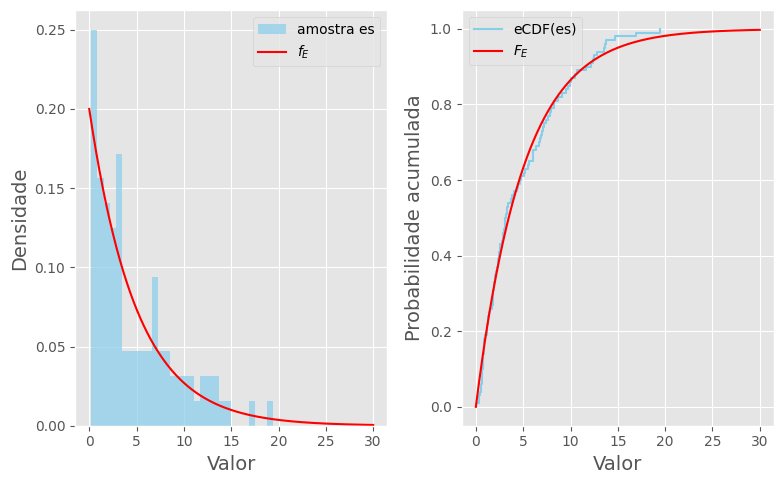

In [57]:
# Compara a amostra exponencial com a PDF e CDF teóricas
fig, axs = plt.subplots(1, 2)
xs = np.linspace(0, 30, 1000)

# histograma da amostra simulada
axs[0].hist(
    es,
    bins=30,
    density=True,
    color='skyblue',
    alpha=0.7,
    label='amostra es'
)
axs[0].plot(xs, rvE.pdf(xs), color='r', label='$f_E$')
axs[0].set_xlabel('Valor')
axs[0].set_ylabel('Densidade')
axs[0].legend()

# distribuição acumulada empírica
sorted_es = np.sort(es)
ecdf = np.arange(1, len(sorted_es) + 1) / len(sorted_es)
axs[1].step(sorted_es, ecdf, where='post', color='skyblue', label='eCDF(es)')
axs[1].plot(xs, rvE.cdf(xs), color='r', label='$F_E$')
axs[1].set_ylim(-0.05, 1.05)
axs[1].set_xlabel('Valor')
axs[1].set_ylabel('Probabilidade acumulada')
axs[1].legend()

plt.tight_layout()
plt.show()
